<a href="https://colab.research.google.com/github/javiermagnone-lab/Javito/blob/main/Tarea_2_ML_analisis_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tarea 2 - ML para analisis de datos**

**Integrantes:** Valentina Corrotti (230707) - Guzmán Momplet (242678) - Javier Magnone (378574)

**Repositorio:** https://github.com/javiermagnone-lab/Javito/blob/main/Tarea_2_ML_analisis_de_datos.ipynb
___________________________________



## **Tareas a realizar:**

|Cuaderno | Tarea |Detalle|
|---|---|---|
|pr_2.ipynb| 2.1| Estudiar las principales características de la variable de respuesta: análisis gráfico de normalidad; opción por la transformación logarítmica. Investigar qué presentan las gráficas qqplot y qué conclusiones podemos extraer acerca de la normalidad de la variable|
|pr_2.ipynb |2.2 | Completar el análisis exploratorio de datos (AED) de variables predictoras, en particular sobre la correlación entre variables predictoras (buscar métodos gráficos para ello) y sus consecuencias en la implementación de regresión|
|pr_2.ipynb |2.3 |Investigar qué es y en qué condiciones conviene realizar la ESTANDARIZACIÓN de variables numéricas en el contexto de regresión para la transformación de variables predictoras numéricas|
|pr_2.ipynb |2.4 |Realizar al menos tres derivaciones del modelo 2 (2.a, 2.b, 2.c) cada una con mayor grado en el polinomio. Analizar los resultados y conclusiones, considerando particularmente la evidencia acerca del problema del sobreajuste. Nota: puede ser seleccionada otra variable para realizar la regresión polinómica, con miras a un mejor desempeño|
|pr_2.ipynb |2.5 |Incorporar más variables. Analizar los resultados y conclusiones, considerando particularmente la evidencia acerca del problema del sobreajuste|
|pr_2_reg_cv.ipynb|2.6 |Analizar los resultados de utilizar validación cruzada, ¿qué conclusiones obtiene?|
|pr_2_reg_cv.ipynb|2.7 |Analizar los resultados al incorporar más variables y aplicar la regularización utilizando Ridge y Lasso, ¿qué conclusiones obtiene? ¿Se cumple la selección de variables alaplicar Lasso?|
|pr_2_reg_cv.ipynb|2.8 |¿Qué conclusiones obtiene? ¿Se cumple la selección de variables al aplicar Lasso? Agregar más variables y comentar los resultados|
|pr_2_reg_cv.ipynb|2.9 |Ídem a 2.8, pero usando Ridge|

# **Cronología del Notebook:**

|# | Sección | Estado|
|---|---|---|
|00| Carga de librerías y dataset| Finalizado|
|01| Preparación de los datos | Finalizado|
|02|Tarea 2.1| Finalizado|
|03|Tarea 2.2| Finalizado|
|04|Tarea 2.3| Finalizado|
|05|Tarea 2.4| Finalizado|
|06|Tarea 2.5| Comenzado|
|07|Tarea 2.6| No Comenzado|
|08|Tarea 2.7| No Comenzado|
|09|Tarea 2.8| No Comenzado|
|10|Tarea 2.9| No Comenzado|



## **00. Carga de librerías y dataset de trabajo**

In [1]:
pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 19.1 MB/s eta 0:00:00


In [91]:
#Librerías

# setup
import os # Obtener directorios de trabajo
import numpy as np
import pandas as pd
import pyreadstat
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
!pip install gdown

## **Carga del dataset de trabajo**

*Resumen*
|Tarea| Código | Estado
|---|---|---|
|Carga del dataset|.sav|Listo|
|Importar data|pd_read_spss|Listo|
|Columnas del dataset|.columns.values.tolist()|Listo|
|Primeras 5 filas|.head()|Listo|


In [4]:
#Carga del dataset

file_id = '13zImdLBAT-WZ3F4jAmloc5ul8nQx2y2V'
output_filename = 'Tarea_2_P_2017_Terceros.sav'
!gdown --id $file_id -O $output_filename

# Update the file_path to point to the downloaded file
file_path = f'/content/{output_filename}'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=13zImdLBAT-WZ3F4jAmloc5ul8nQx2y2V
From (redirected): https://drive.google.com/uc?id=13zImdLBAT-WZ3F4jAmloc5ul8nQx2y2V&confirm=t&uuid=5bf83a73-91f6-4b22-ad53-30df28a28cec
To: /content/Tarea_2_P_2017_Terceros.sav
100% 115M/115M [00:03<00:00, 32.7MB/s]


In [5]:
# import data

dfP2017 = pd.read_spss(r'Tarea_2_P_2017_Terceros.sav')

In [6]:
# Columnas del dataset
columns = dfP2017.columns.values.tolist()
print(columns)

['numero', 'nper', 'anio', 'mes', 'dpto', 'nomdpto', 'secc', 'segm', 'loc_agr_13', 'nom_loc_agr_13', 'ccz', 'barrio', 'nombarrio', 'estred13', 'region_3', 'region_4', 'pesoano', 'pesosem', 'pesotri', 'pesomen', 'e557', 'e558', 'e26', 'e27', 'e29_1', 'e29_2', 'e29_3', 'e29_4', 'e29_5', 'e29_5_1', 'e29_6', 'e30', 'e31', 'e32', 'e33', 'e34', 'e35', 'e36', 'e185', 'e186_1', 'e186_2', 'e186_3', 'e186_4', 'e37', 'e37_2', 'e234_2', 'e38', 'e38_1', 'e39', 'e39_2', 'e235_2', 'e236', 'e236_2', 'e236_4', 'e45_1', 'e45_1_1', 'e45_1_1_1', 'e45_1_2', 'e45_1_2_1', 'e45_2', 'e45_2_1', 'e45_2_1_1', 'e45_2_2', 'e45_2_2_1', 'e45_3', 'e45_3_1', 'e45_3_1_1', 'e45_3_2', 'e45_3_2_1', 'e45_4', 'e45_4_1', 'e45_4_2', 'e45_4_3', 'e45_4_3_1', 'e45_5', 'e45_5_1', 'e45_5_1_1', 'e45_6', 'e45_7', 'e45_7_1', 'e237', 'e46', 'e47', 'e47_1', 'e190', 'e190_1', 'e190_1_1', 'e190_2', 'e190_2_1', 'e190_3', 'e190_3_1', 'e191', 'e192', 'e48', 'e49', 'e238', 'e239', 'e240_1', 'e240_2', 'e241', 'e242', 'e242_1', 'e193', 'e194', 

In [7]:
# Primeras 5 filas del dataset
dfP2017.head()

,numero,nper,anio,mes,dpto,nomdpto,secc,segm,loc_agr_13,nom_loc_agr_13,...,indaceliac,indatuberc,indaoncolo,indasida,indaucc,PT1,PT2,PT4,pobre06,indigente06
0,2017000001,1.0,2017,Enero,Montevideo,MONTEVIDEO,17,006,01010,Montevideo,...,689.0,585.0,585.0,585.0,665.0,28779.0,28779.0,28779.0,0.0,0.0
1,2017000001,2.0,2017,Enero,Montevideo,MONTEVIDEO,17,006,01010,Montevideo,...,689.0,585.0,585.0,585.0,665.0,10100.0,0.0,0.0,0.0,0.0
2,2017000002,1.0,2017,Junio,Canelones,CANELONES,,,03023,"Canelones y otras (Paso Espinosa, Paso Palomeque)",...,691.0,578.0,578.0,578.0,672.0,50786.0,50786.0,50786.0,0.0,0.0
3,2017000002,2.0,2017,Junio,Canelones,CANELONES,,,03023,"Canelones y otras (Paso Espinosa, Paso Palomeque)",...,691.0,578.0,578.0,578.0,672.0,0.0,0.0,0.0,0.0,0.0
4,2017000003,1.0,2017,Febrero,Montevideo,MONTEVIDEO,24,108,01010,Montevideo,...,688.0,585.0,585.0,585.0,662.0,88000.0,0.0,0.0,0.0,0.0


# 01. Preparación de los datos

* Variables de nuestro caso de estudio
    - variable de respuesta: Se crea la variable ysos_dep como la suma de los importes monetarios recibidos el mes anterior por concepto de sueldos y jornales, comisiones y otros conceptos variables, viáticos y propinas, recibidos en relación de dependencia, tanto en su ocupación principal como en otras en relación de dependencia

* Variables categóricas (https://pandas.pydata.org/docs/user_guide/categorical.html)
    - decisión: transformamos las variables categóricas si se importan como numéricas, definiendo su tipo al incorporarlas a nuestro dataset
    - en este caso no sería necesario ya que las que son de nuestro interés se importaron como categóricas


In [8]:
df_ysos = pd.DataFrame()

# variable de respuesta
df_ysos['ysos_dep'] = dfP2017['g126_1'] + dfP2017['g126_2'] + dfP2017['g126_3'] + dfP2017['g126_4'] \
                      + dfP2017['g134_1'] + dfP2017['g134_2'] + dfP2017['g134_3'] + dfP2017['g134_4']

# atributos

## caracteristicas personales
df_ysos['edad'] = dfP2017['e27']
df_ysos['sexo'] = dfP2017['e26']

## educación
df_ysos['anios_educ'] = dfP2017['e51_2'] + dfP2017['e51_3'] + dfP2017['e51_4'] + dfP2017['e51_5'] + dfP2017['e51_6'] \
                        + dfP2017['e51_7'] + dfP2017['e51_8'] + dfP2017['e51_9'] + dfP2017['e51_10'] + dfP2017['e51_11']

## relación de empleo
df_ysos['antiguedad'] = dfP2017['f88_2']
df_ysos['categoria_ocup'] = dfP2017['f73']

df_ysos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118268 entries, 0 to 118267
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   ysos_dep        118268 non-null  float64 
 1   edad            118268 non-null  float64 
 2   sexo            118268 non-null  category
 3   anios_educ      118268 non-null  float64 
 4   antiguedad      118268 non-null  float64 
 5   categoria_ocup  118268 non-null  category
dtypes: category(2), float64(4)
memory usage: 3.8 MB


In [9]:
#Encabezados

df_ysos.head()

,ysos_dep,edad,sexo,anios_educ,antiguedad,categoria_ocup
0,18000.0,70.0,Hombre,6.0,7.0,Asalariado/a privado/a
1,0.0,81.0,Mujer,4.0,0.0,0.0
2,48000.0,52.0,Hombre,6.0,32.0,Asalariado/a público/a
3,0.0,15.0,Hombre,15.0,0.0,0.0
4,0.0,72.0,Mujer,16.0,0.0,0.0


* Filtro de observaciones relevantes
    - tomamos la decisión de considerar exclusivamente las observaciones con valores mayores que cero de la variable de respuesta (la persona se encuentra trabajando y cobra por su trabajo)
    

In [10]:
# podemos filtrar acá: como se respeta el índice, incluso podríamos considerar luego otras variables del dataset original

df_ysos = df_ysos[df_ysos['ysos_dep'] > 0]

In [11]:
# nota: las operaciones de filtro (arrays de numpy) mantienen el vínculo índice-valor:
df_ysos.index

Index([     0,      2,      5,      7,      8,     13,     15,     16,     20,
           27,
       ...
       118238, 118239, 118247, 118249, 118252, 118254, 118256, 118257, 118261,
       118262],
      dtype='int64', length=38998)

categoria_ocup
0.0                                                 808
Asalariado/a privado/a                            29166
Asalariado/a público/a                             8219
Cuenta propia con local o inversión                 560
Cuenta propia sin local ni inversión                 58
Miembro de cooperativa de producción o trabajo        9
Miembro del hogar no remunerado                       1
Patrón/a                                             86
Trabajador/a de un programa social de empleo         91
Name: ysos_dep, dtype: int64
categoria_ocup
0.0                                               0.020719
Asalariado/a privado/a                            0.747885
Asalariado/a público/a                            0.210754
Cuenta propia con local o inversión               0.014360
Cuenta propia sin local ni inversión              0.001487
Miembro de cooperativa de producción o trabajo    0.000231
Miembro del hogar no remunerado                   0.000026
Patrón/a                

/tmp/ipykernel_1952/3864018315.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count())
/tmp/ipykernel_1952/3864018315.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count()/len(df_ysos))


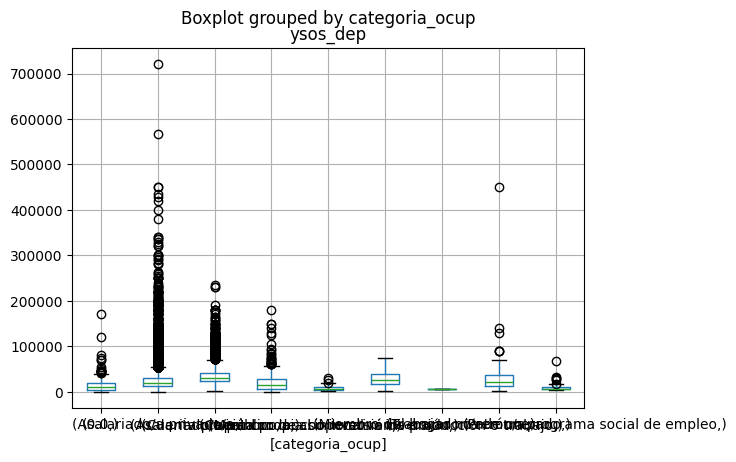

In [12]:
df_ysos.boxplot(column=['ysos_dep'], by=['categoria_ocup']);
print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count())
print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count()/len(df_ysos))

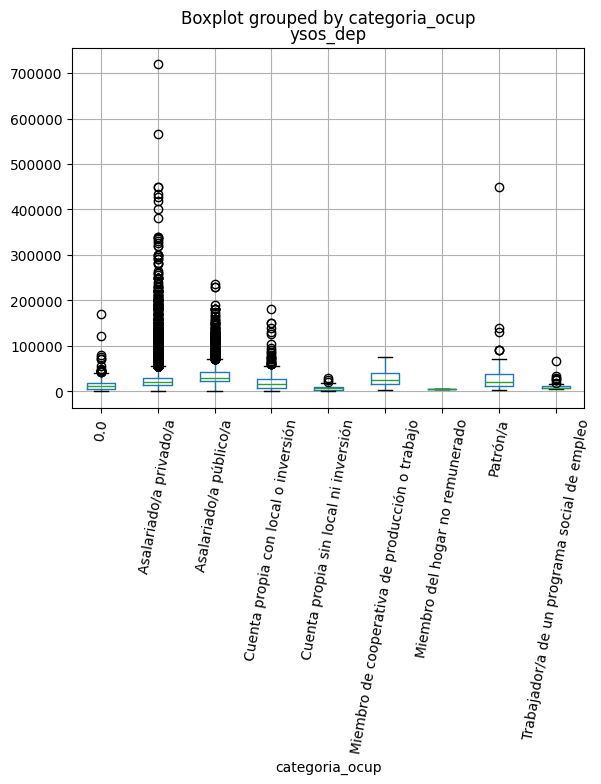

In [13]:
## — 1.  Pinta el boxplot
ax = df_ysos.boxplot(column='ysos_dep', by='categoria_ocup')
## — 2.  Rota etiquetas eje X
ax.tick_params(axis='x', rotation=80)
## — 3.  Imprimir
plt.show();

In [14]:
df_ysos = df_ysos.loc[(df_ysos['categoria_ocup'] == "Asalariado/a privado/a") | (df_ysos['categoria_ocup'] == "Asalariado/a público/a")]

In [15]:
df_ysos['categoria_ocup'].head()

,categoria_ocup
0,Asalariado/a privado/a
2,Asalariado/a público/a
5,Asalariado/a privado/a
7,Asalariado/a privado/a
8,Asalariado/a privado/a


## **02. Tarea 2.1**
Estudiar las principales características de la variable de respuesta: análisis gráfico de normalidad; opción por la transformación logarítmica. Investigar qué presentan las gráficas qqplot y qué conclusiones podemos extraer acerca de la normalidad de la variable

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Variable respuesta: Gráfico| Finalizado|
|b| Variable respuesta: QQPLot|Finalizado|
|c|Normalizo aplicando Logaritmo la variable de respuesta|Finalizado|
|d|Visualizo qqplot luego de Logartimización|Finalizado|
|e|Defino nuevo dataset con variable de respuesta normalizada| Finalizado|
|f|Comportamiento de la variable de respuesta vs variables predictoras| Finalizado|
|g|plotear distribución del dataset| Finalizado|









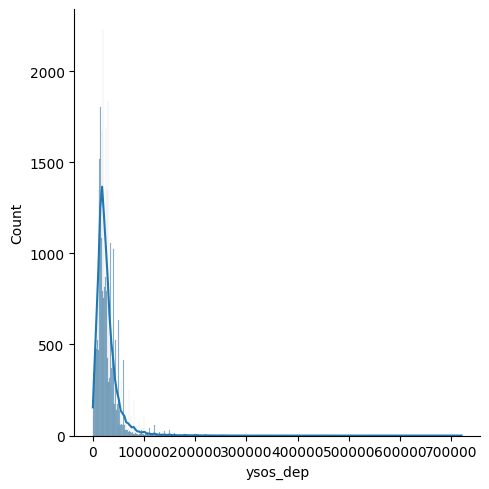

In [16]:
# a: Gráfico variable respuesta

sns.displot(df_ysos['ysos_dep'], kde = True)

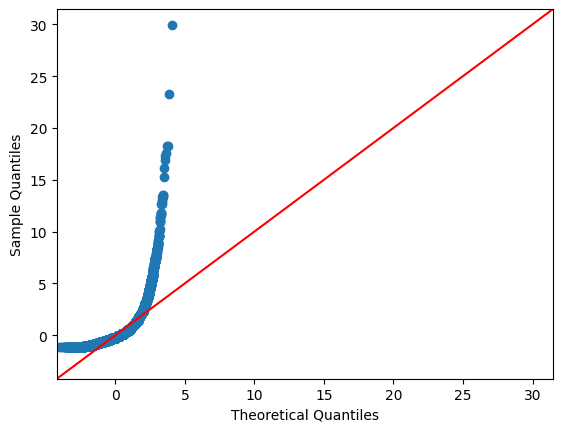

In [17]:
# b. Gráfico qqplot (¿Para que?)

sm.qqplot(np.array(df_ysos['ysos_dep']), line='45', fit=True);

### *Resumen Teorico:*

- Los QQPLOT son gráficos que comparan dos distribuciones de probabilidad enfrentando sus cuantiles. Se usa para evaluar si los datos siguen una distribución teorica.

- Se ordenan los datos de menor a mayor y se calculan sus cuantiles empíricos. Luego se grafican contra los cuantiles teóricos esperados de la distribución de referencia:

- Eje X → cuantiles teóricos (ej: distribución normal estándar)
Eje Y → cuantiles observados en los datos

- Si los datos siguen esa distribución, los puntos caen sobre una línea recta diagonal.

- En este caso: Curva pronunciada hacia arriba con puntos muy alejados de la linea roja en la parte superior. Esto indica un sesgo positivo muy fuerte, la distribución esta lejos de ser normal, hay valores extremos en 23 y 30 (aprox) que se disparan del resto.




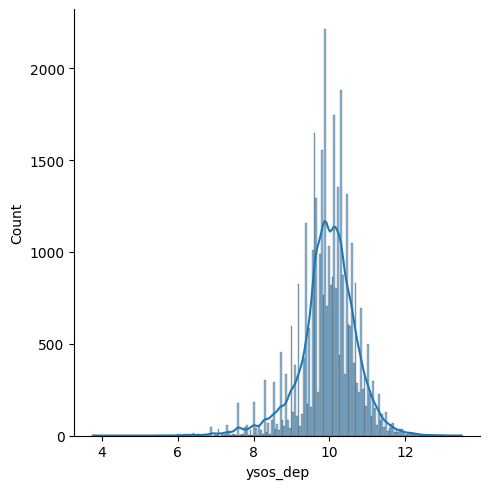

In [18]:
# C. Normalizo aplicando Logaritmo la variable de respuesta

sns.displot(np.log(df_ysos['ysos_dep']), kde = True)

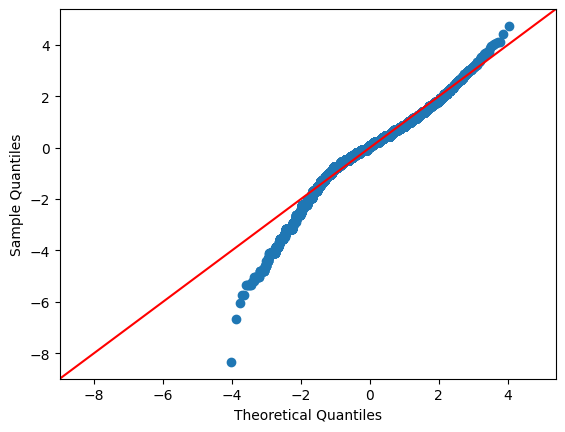

In [19]:
# d. Visualizo qqplot luego de Logartimización

sm.qqplot(np.array(np.log(df_ysos['ysos_dep'])), line='45', fit=True); #punto y coma evita duplicación del gráfico

QQPLOT: mejora la normalización en los puntos centrales PERO se observa un nuevo problema en la cola izquierda.
- Esto sugiere outliers negativos tras aplicar el logaritmo (valores muy cercanos a cero)
- Se puede considerar transformación log (x+1) o Box-Cox

In [20]:
# d' - Aplico transformación log(x+1)

df_ysos["log1_ysos_dep"] = np.log1p(df_ysos["ysos_dep"])

,ysos_dep
count,37385.000000
mean,27318.851892
std,23157.617331
min,43.000000
25%,15000.000000
50%,22000.000000
75%,33000.000000
max,720000.000000


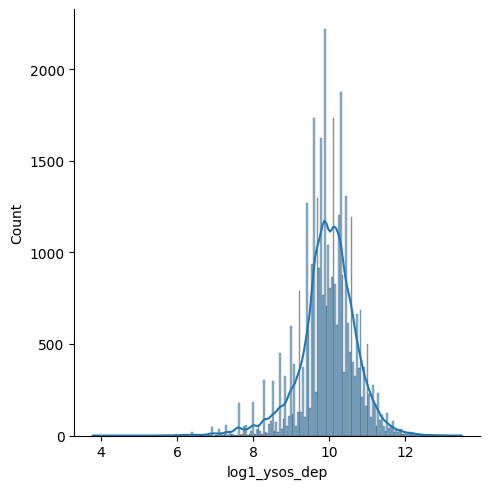

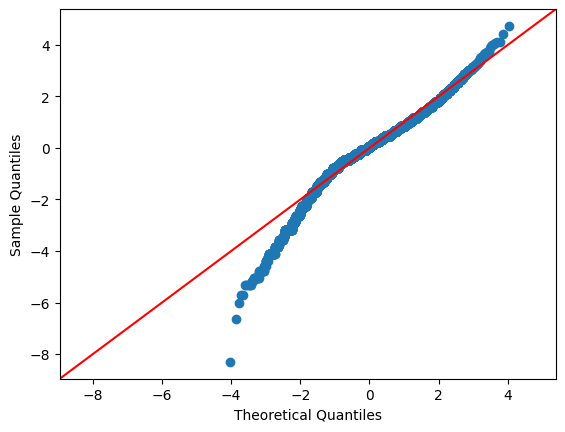

In [21]:
# d' - Analizo nueva normalización - Realizo un describe de los datos (para garantizar que no hayan ceros)

sns.displot((df_ysos['log1_ysos_dep']), kde = True)
sm.qqplot(np.array(df_ysos['log1_ysos_dep']), line='45', fit=True);
df_ysos['ysos_dep'].describe()


## **Conclusiones - Tarea 2.1:**

- La variable ysos_dep presenta una distribución fuertemente asimétrica (sesgo positivo), con valores entre 43 y 720.000 y una desviación estándar de 23.157.
 - Se aplicó una transformación logarítmica log(1+x) y log(x) para estabilizar la varianza, reducir el efecto de valores extremos y aproximar la linealidad con la variable dependiente.

- La desviación observada en las colas del QQ-plot es inherente a la distribución de la variable y no compromete la validez del modelo dado el tamaño muestral (n = 37.385)."

- Puedo utilizar cualquier log(x) o log(x+1)

## **03. Tarea 2.2**
Completar el análisis exploratorio de datos (AED) de variables predictoras, en particular sobre la correlación entre variables predictoras (buscar métodos gráficos para ello) y sus consecuencias en la implementación de regresión

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Defino nuevo dataset | Listo |
|b| Comportamiento variables según variable predictora| Listo|
|c1| Anios educación según Var respuesta, Distribución| Listo
|c2| Anios educación vs Respuesta: Boxplot y Mediana (log) ingreso| Listo
|c3| Anios educación - Frecuencia (Histograma) | Listo
|d1| Categoria ocupación. Count de casos (Respeto la agrupación realizada al inicio del Notebook)| Listo
|d2|Categoria ocupación (binaria). Cantidad de casos| Listo
|d3| Categoria ocupacion: Boxplot| Listo
|e1|Edad vs Var respuesta: Distribución| Listo
|e2|Edad vs Var respuesta: Boxplot y mediana con agrupación por Bins| Listo
|f1|Antiguedad vs Var respuesta| Listo|
|f2| Antiguedad vs Var respuesta: Boxplot y mediana con agrupación por Bins | Listo
|f3| Antiguedad: Distribución de casos| Listo
|g1| Sexo: Distribucion de casos| Listo
|g2| Sexo: Boxplot y mediana de ingresos| Listo
|h| Correlación| Listo
|h2| Correlación: conclusiones finales| Se puede mejorar|









In [22]:
# a. Defino nuevo dataset con variable de respuesta normalizada

df_ysos['l_ysos_dep'] = np.log(df_ysos['ysos_dep'])
df_l_ysos = df_ysos.drop(columns=['ysos_dep'])
df_l_ysos.head()

,edad,sexo,anios_educ,antiguedad,categoria_ocup,log1_ysos_dep,l_ysos_dep
0,70.0,Hombre,6.0,7.0,Asalariado/a privado/a,9.798183,9.798127
2,52.0,Hombre,6.0,32.0,Asalariado/a público/a,10.778977,10.778956
5,42.0,Mujer,16.0,0.0,Asalariado/a privado/a,10.404293,10.404263
7,29.0,Mujer,8.0,1.0,Asalariado/a privado/a,7.783641,7.783224
8,37.0,Hombre,6.0,4.0,Asalariado/a privado/a,10.043293,10.043249


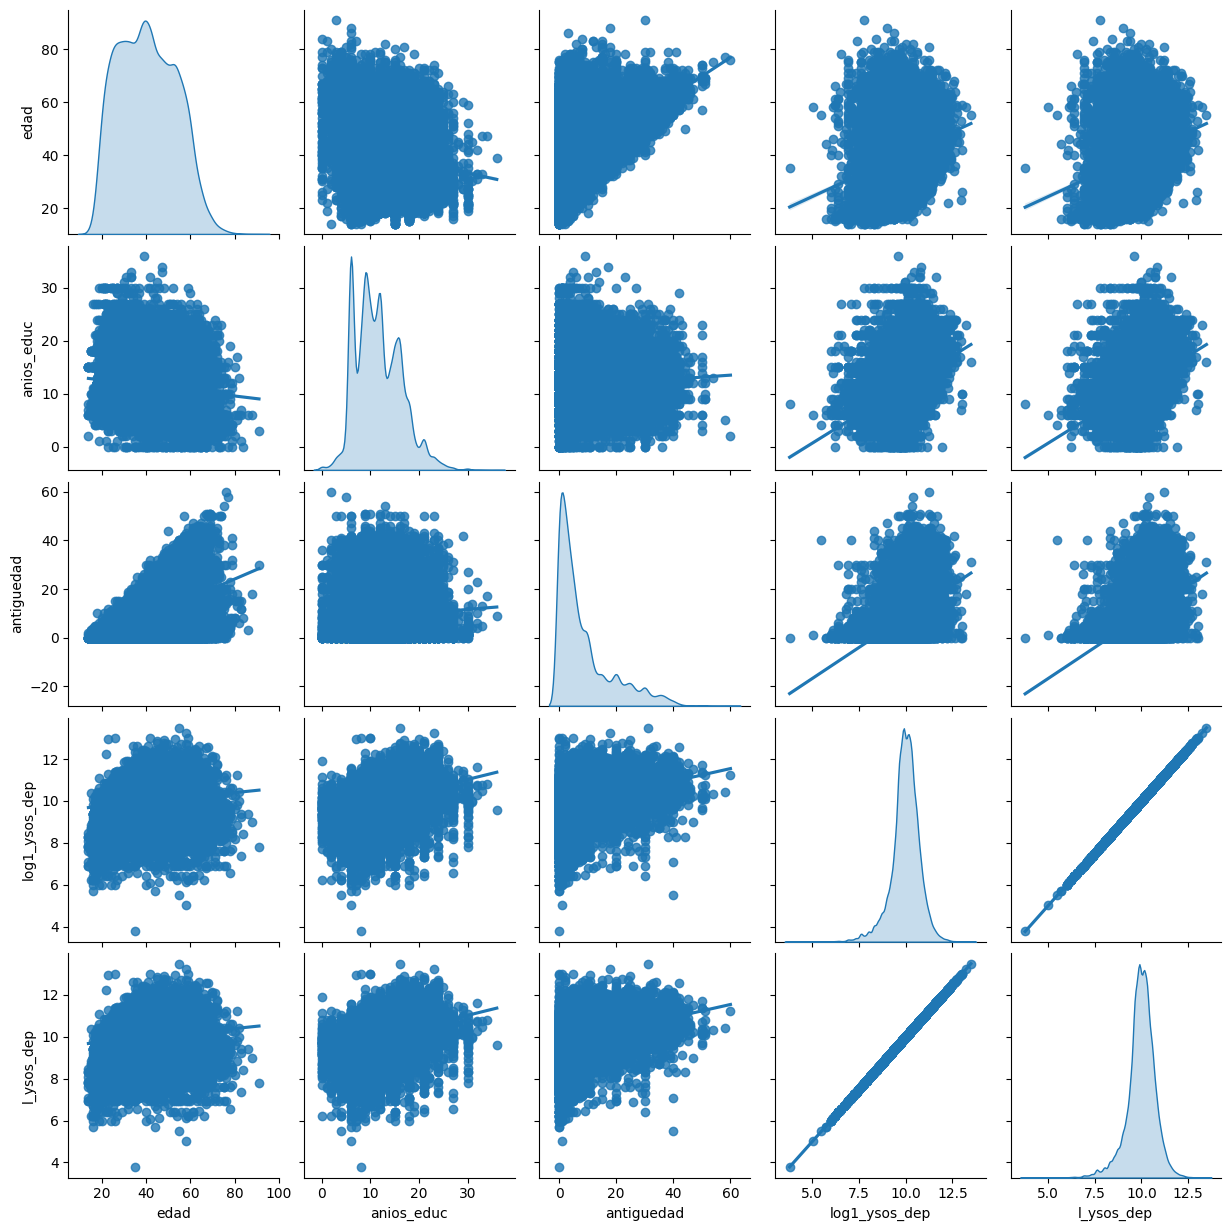

In [23]:
# b. Comportamiento de la variable de respuesta vs variables predictoras

sns.pairplot(df_l_ysos, kind="reg", diag_kind="kde")

- *Variable: Anios educación:*

In [24]:
df_ysos["anios_educ"].describe()

,anios_educ
count,37385.000000
mean,11.556079
std,4.599975
min,0.000000
25%,8.000000
50%,11.000000
75%,15.000000
max,36.000000


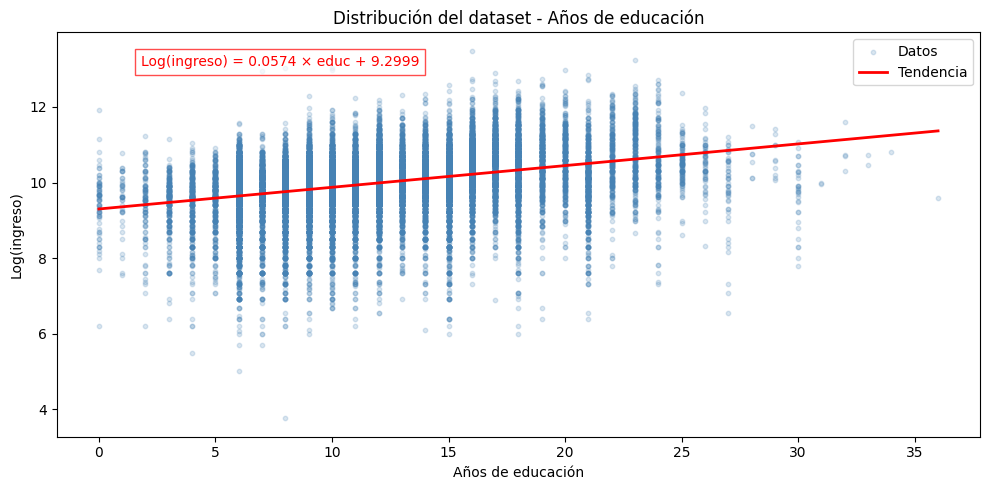

In [25]:
# c1. Anios educación vs Respuesta: Distribución

plt.figure(figsize=(10,5))
plt.scatter(df_l_ysos['anios_educ'], df_l_ysos['l_ysos_dep'],
            alpha=0.2, s=10, color='steelblue', label='Datos')

z = np.polyfit(df_l_ysos['anios_educ'].dropna(), df_l_ysos['l_ysos_dep'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df_l_ysos['anios_educ'].min(), df_l_ysos['anios_educ'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia')

# Ecuación en el gráfico
plt.text(x=df_l_ysos['anios_educ'].max() * 0.05,
         y=df_l_ysos['l_ysos_dep'].max() * 0.97,
         s=f'Log(ingreso) = {z[0]:.4f} × educ + {z[1]:.4f}',
         fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.7))

plt.title('Distribución del dataset - Años de educación')
plt.xlabel('Años de educación')
plt.ylabel('Log(ingreso)')
plt.legend()
plt.tight_layout()
plt.show()

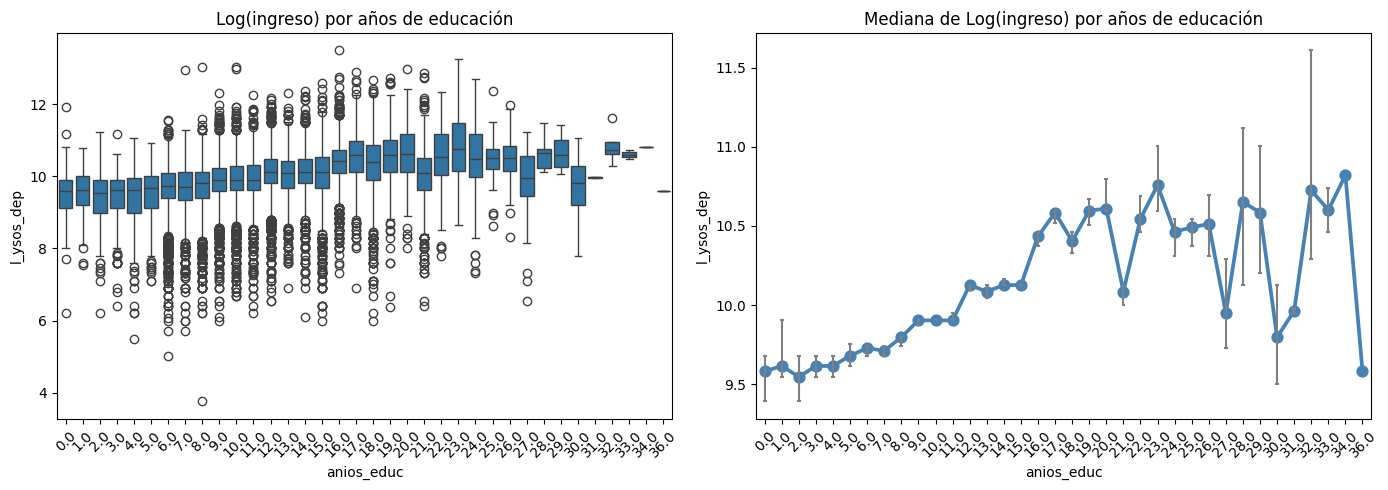

In [26]:
# c2. Anios educación vs Respuesta: Boxplot y Mediana (log) ingreso

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='anios_educ', y='l_ysos_dep', data=df_l_ysos, ax=axes[0])
axes[0].set_title('Log(ingreso) por años de educación')
axes[0].tick_params(axis='x', rotation=45)

# Mediana con intervalo de confianza
sns.pointplot(x='anios_educ', y='l_ysos_dep', data=df_l_ysos, ax=axes[1],
              estimator=np.median, capsize=0.1, color='steelblue',
              err_kws={'color': 'grey', 'linewidth': 1.5})
axes[1].set_title('Mediana de Log(ingreso) por años de educación')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

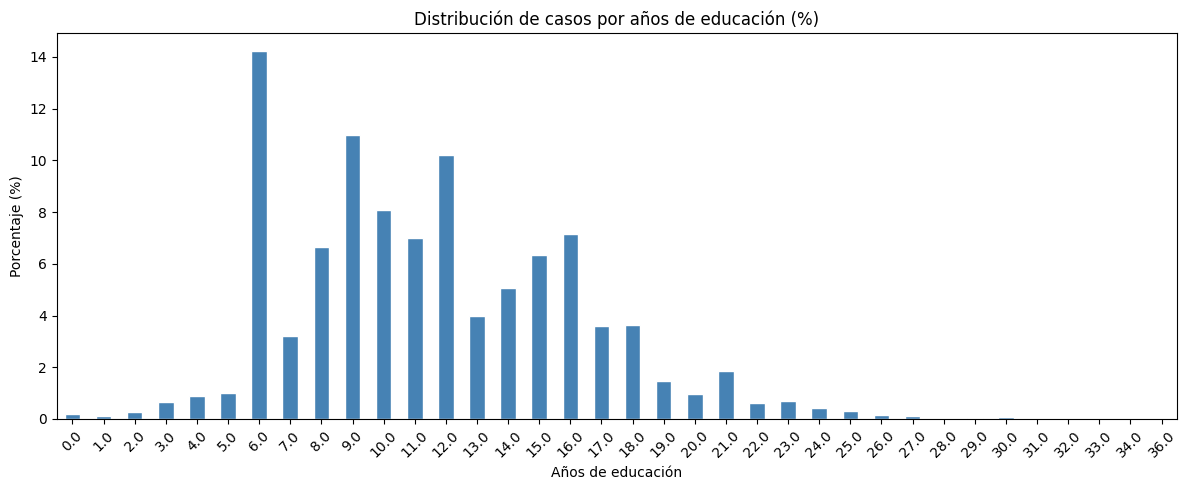

In [27]:
# c3. Anios educación - Frecuencia (Histograma):

plt.figure(figsize=(12, 5))

conteo = df_l_ysos['anios_educ'].value_counts().sort_index()
porcentaje = conteo / conteo.sum() * 100

porcentaje.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Distribución de casos por años de educación (%)')
plt.xlabel('Años de educación')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Primeras consideraciones: Anios educación vs Var. respuesta

- Si bien existe una gran variabilidad a medida que aumentan los años, se observa que al aumentar los años de educación aumenta el ingreso.
- Los picos de la distribución (6, 9, 12 y 16 años) coinciden con los ciclos del sistema educativo uruguayo (primaria, ciclo básico, bachillerato y universidad), evidenciando que el abandono ocurre al finalizar cada nivel formal.
- Los outliers estan relacionados con la cantidad de casos presentes en los anios de educacion realizados.



- *Variable: Categoria ocupación*

In [28]:
# d1. Categoria ocupación. Count de casos (Respeto la agrupación realizada al inicio del Notebook)

df_l_ysos['categoria_ocup'] = df_l_ysos['categoria_ocup'].cat.remove_unused_categories()

conteo = df_l_ysos['categoria_ocup'].value_counts()
porcentaje = conteo / conteo.sum() * 100

resultado = pd.DataFrame({'Casos': conteo, 'Porcentaje (%)': porcentaje.round(1)})
print(resultado)



                        Casos  Porcentaje (%)
categoria_ocup                               
Asalariado/a privado/a  29166            78.0
Asalariado/a público/a   8219            22.0


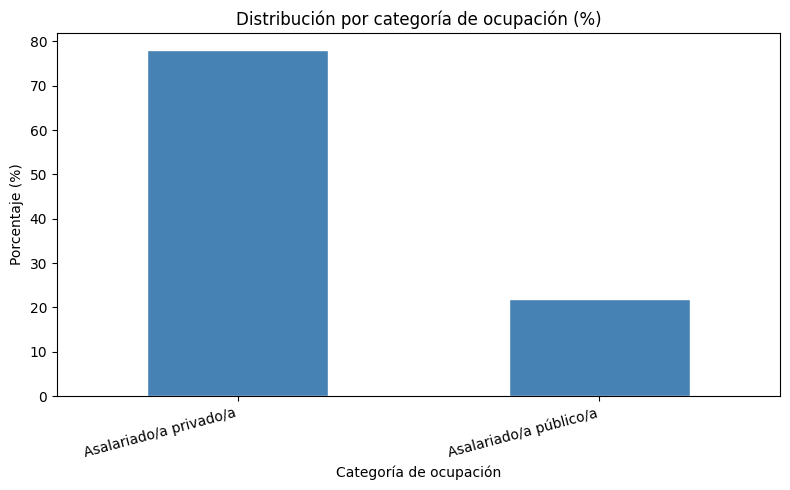

In [29]:
#d2. Categoria ocupación (binaria). Cantidad de casos

plt.figure(figsize=(8, 5))

porcentaje = df_l_ysos['categoria_ocup'].value_counts() / len(df_l_ysos) * 100
porcentaje.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Distribución por categoría de ocupación (%)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Categoría de ocupación')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()



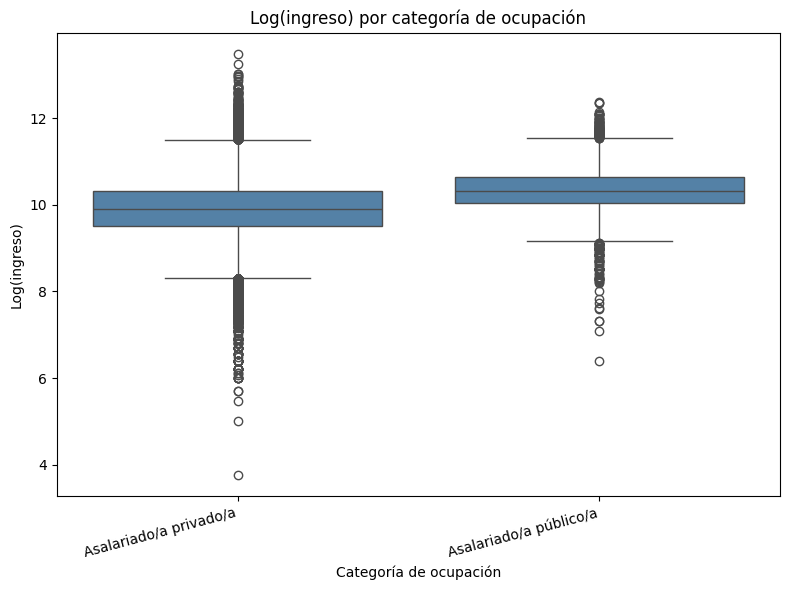

                             mean     median       std
categoria_ocup                                        
Asalariado/a privado/a   9.853802   9.903488  0.763597
Asalariado/a público/a  10.350349  10.308953  0.506503


/tmp/ipykernel_1952/1956234347.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_l_ysos.groupby('categoria_ocup')['l_ysos_dep'].agg(['mean', 'median', 'std']))


In [30]:
# d3. Categoria ocupacion: Boxplot

plt.figure(figsize=(8, 6))

sns.boxplot(x='categoria_ocup', y='l_ysos_dep', data=df_l_ysos, color='steelblue')

plt.title('Log(ingreso) por categoría de ocupación')
plt.xlabel('Categoría de ocupación')
plt.ylabel('Log(ingreso)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(df_l_ysos.groupby('categoria_ocup')['l_ysos_dep'].agg(['mean', 'median', 'std']))


## Primeras consideraciones: Ocupación (binaria) vs Var. respuesta

- Hay un desbalance entre las categorias (78 % vs 22 %)
- Los asalariados publicos ganan mas


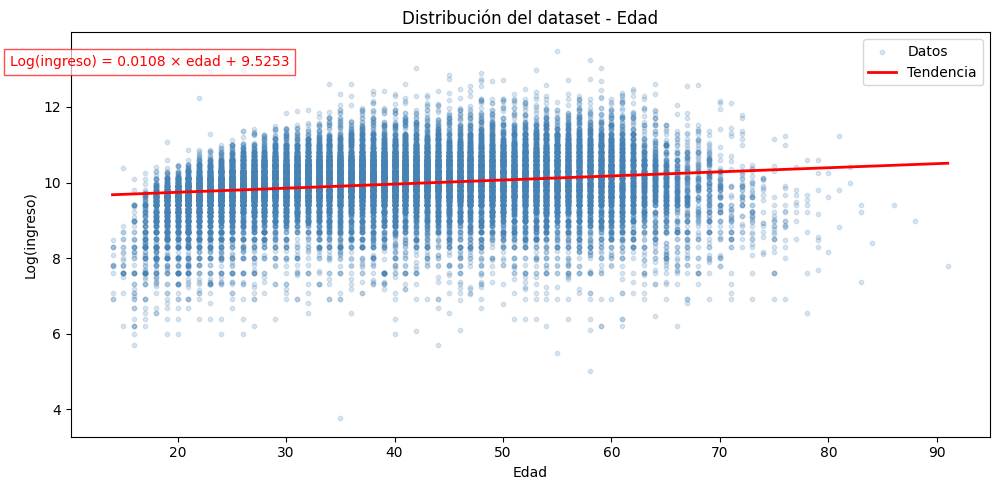

In [31]:
# e1. Edad vs Var respuesta: Distribución

plt.figure(figsize=(10, 5))
plt.scatter(df_l_ysos['edad'], df_l_ysos['l_ysos_dep'],
            alpha=0.2, s=10, color='steelblue', label='Datos')

# Línea de tendencia
z = np.polyfit(df_l_ysos['edad'].dropna(), df_l_ysos['l_ysos_dep'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df_l_ysos['edad'].min(), df_l_ysos['edad'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia')

# Ecuación en el gráfico
plt.text(x=df_l_ysos['edad'].max() * 0.05,
         y=df_l_ysos['l_ysos_dep'].max() * 0.97,
         s=f'Log(ingreso) = {z[0]:.4f} × edad + {z[1]:.4f}',
         fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.7))

plt.title('Distribución del dataset - Edad')
plt.xlabel('Edad')
plt.ylabel('Log(ingreso)')
plt.legend()
plt.tight_layout()
plt.show()


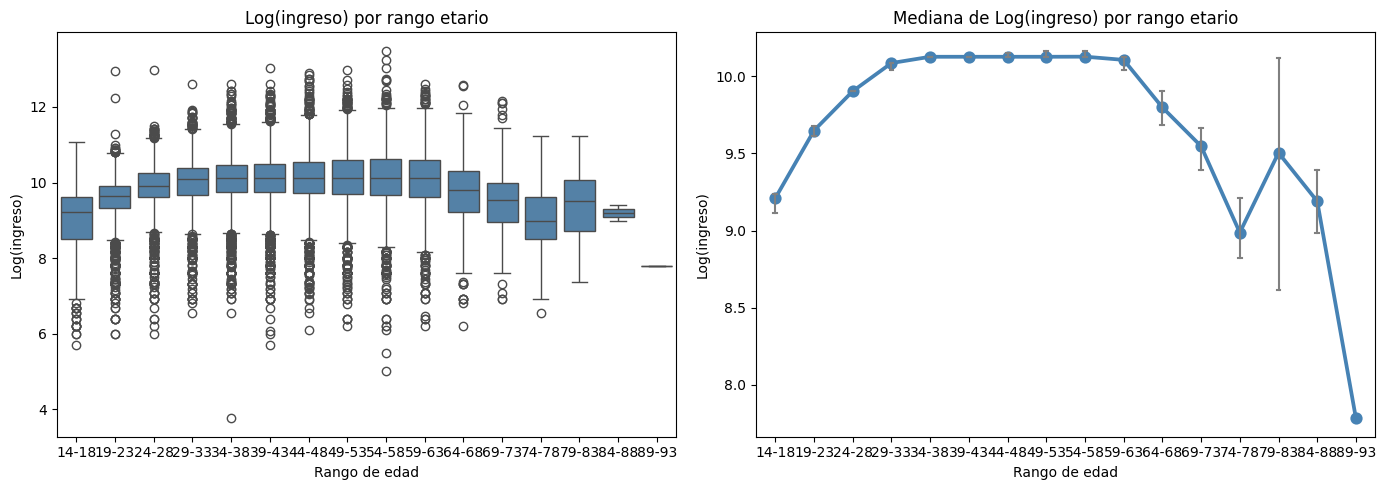

In [32]:
# e2. Edad vs Var respuesta: Boxplot y mediana con agrupación por Bins
# La selección de Bins es arbitraria para visualizar

df_l_ysos['rango_edad'] = pd.cut(df_l_ysos['edad'],
                                  bins=range(14, 96, 5),
                                  labels=[f'{i}-{i+4}' for i in range(14, 91, 5)])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='rango_edad', y='l_ysos_dep', data=df_l_ysos, ax=axes[0], color='steelblue')
axes[0].set_title('Log(ingreso) por rango etario')
axes[0].set_xlabel('Rango de edad')
axes[0].set_ylabel('Log(ingreso)')

sns.pointplot(x='rango_edad', y='l_ysos_dep', data=df_l_ysos, ax=axes[1],
              estimator=np.median, capsize=0.1, color='steelblue',
              err_kws={'color': 'grey', 'linewidth': 1.5})
axes[1].set_title('Mediana de Log(ingreso) por rango etario')
axes[1].set_xlabel('Rango de edad')
axes[1].set_ylabel('Log(ingreso)')

plt.tight_layout()
plt.show()

## Primeras consideraciones: Edad vs Var. respuesta

- El ingreso sube  hasta los 50-55 años y luego cae
- La forma de parabola puede considerarse para el modelo.


## Variable: Antiguedad

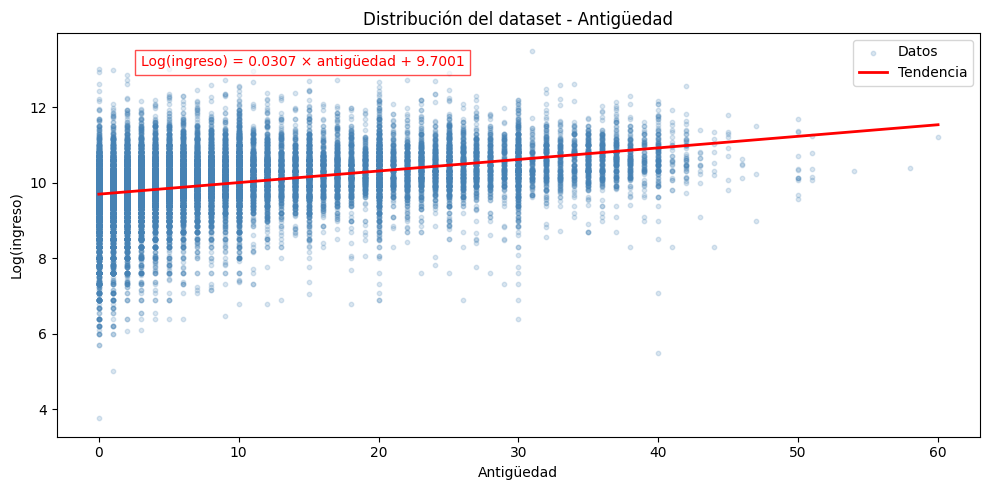

In [33]:
# f1. Antiguedad vs Var respuesta

plt.figure(figsize=(10, 5))
plt.scatter(df_l_ysos['antiguedad'], df_l_ysos['l_ysos_dep'],
            alpha=0.2, s=10, color='steelblue', label='Datos')

z = np.polyfit(df_l_ysos['antiguedad'].dropna(), df_l_ysos['l_ysos_dep'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df_l_ysos['antiguedad'].min(), df_l_ysos['antiguedad'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia')

plt.text(x=df_l_ysos['antiguedad'].max() * 0.05,
         y=df_l_ysos['l_ysos_dep'].max() * 0.97,
         s=f'Log(ingreso) = {z[0]:.4f} × antigüedad + {z[1]:.4f}',
         fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.7))

plt.title('Distribución del dataset - Antigüedad')
plt.xlabel('Antigüedad')
plt.ylabel('Log(ingreso)')
plt.legend()
plt.tight_layout()
plt.show()


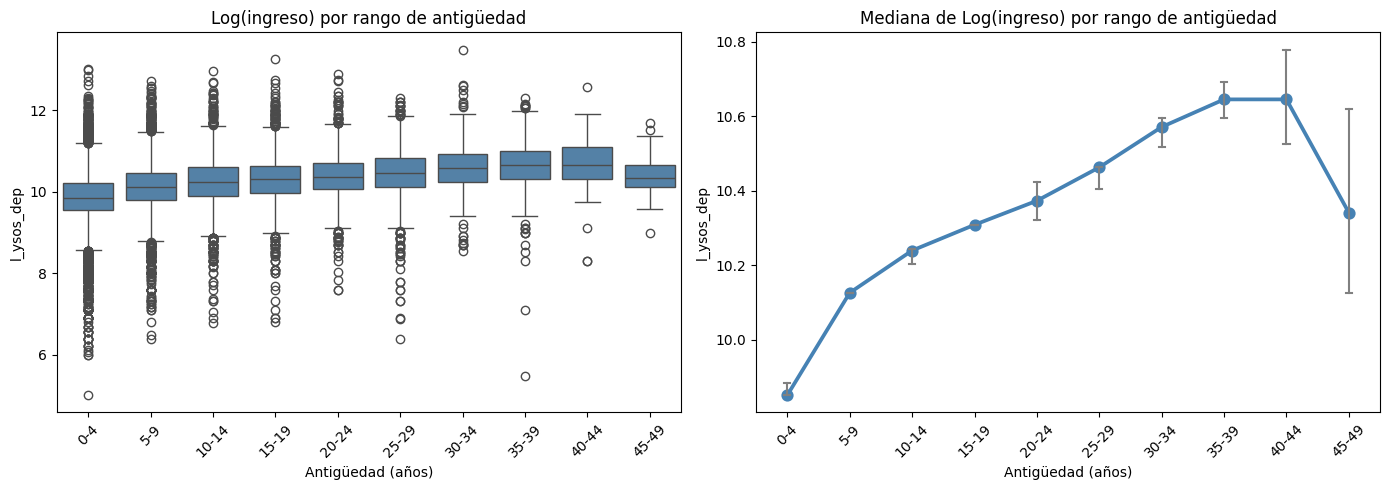

In [34]:
# f2 Antiguedad vs Var respuesta: Boxplot y mediana con agrupación por Bins
# La selección de Bins es arbitraria para visualizar

df_l_ysos['rango_antig'] = pd.cut(df_l_ysos['antiguedad'],
                                   bins=range(0, 55, 5),
                                   labels=[f'{i}-{i+4}' for i in range(0, 50, 5)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='rango_antig', y='l_ysos_dep', data=df_l_ysos, ax=axes[0], color='steelblue')
axes[0].set_title('Log(ingreso) por rango de antigüedad')
axes[0].set_xlabel('Antigüedad (años)')
axes[0].tick_params(axis='x', rotation=45)

sns.pointplot(x='rango_antig', y='l_ysos_dep', data=df_l_ysos, ax=axes[1],
              estimator=np.median, capsize=0.1, color='steelblue',
              err_kws={'color': 'grey', 'linewidth': 1.5})
axes[1].set_title('Mediana de Log(ingreso) por rango de antigüedad')
axes[1].set_xlabel('Antigüedad (años)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


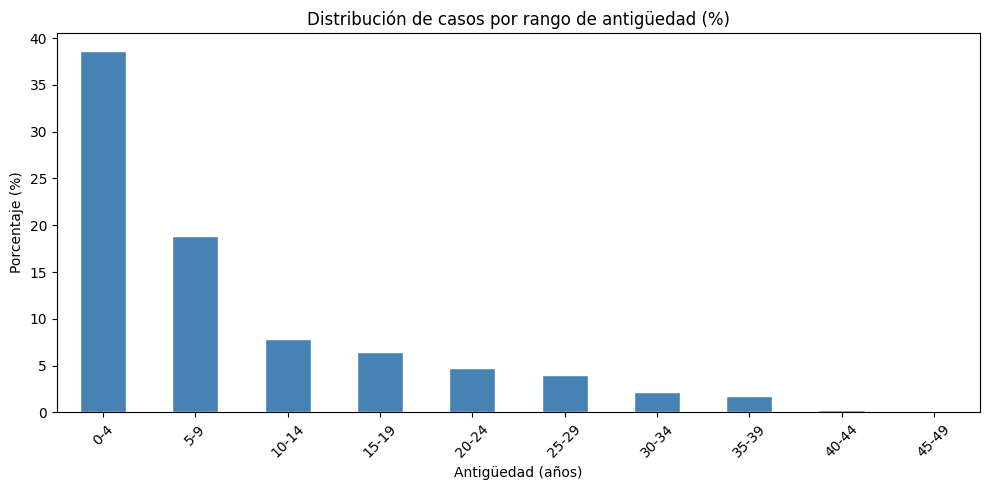

In [35]:
#f3. Antiguedad: Distribución de casos

plt.figure(figsize=(10, 5))
porcentaje = df_l_ysos['rango_antig'].value_counts().sort_index() / len(df_l_ysos) * 100
porcentaje.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribución de casos por rango de antigüedad (%)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Antigüedad (años)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Primeras consideraciones variable antiguedad:
- La antigüedad presenta una relación positiva con el ingreso
- La distribución está fuertemente concentrada en trabajadores con menos de 10 años de antigüedad (~57% de la muestra), lo que genera mayor variabilidad en ese tramo.

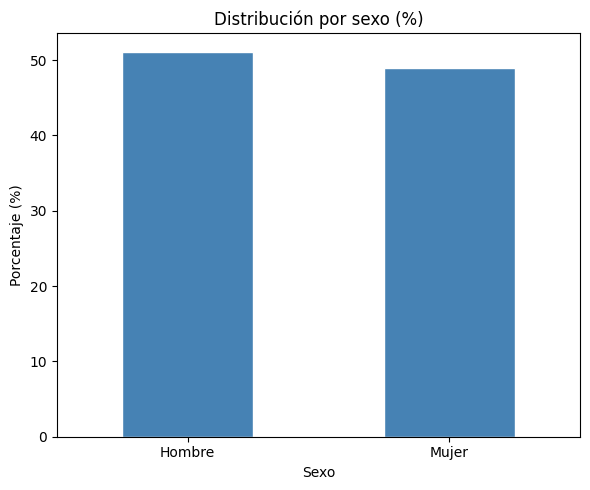

In [36]:
# g2. Variable Sexo: Distribución de casos

plt.figure(figsize=(6, 5))
porcentaje = df_l_ysos['sexo'].value_counts() / len(df_l_ysos) * 100
porcentaje.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribución por sexo (%)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Sexo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


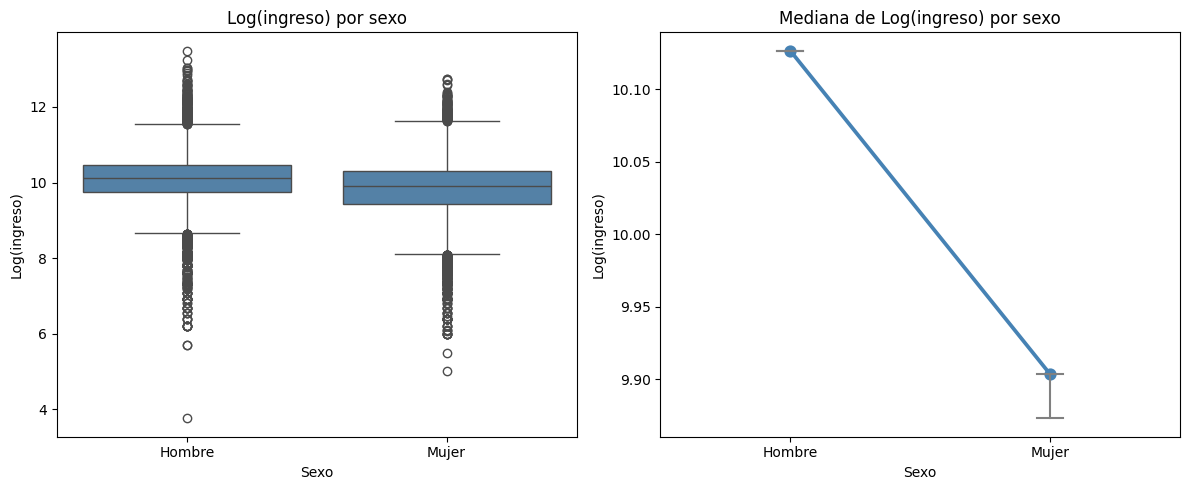

             mean     median       std
sexo                                  
Hombre  10.099426  10.126631  0.673121
Mujer    9.820548   9.903488  0.786609


/tmp/ipykernel_1952/2476334508.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_l_ysos.groupby('sexo')['l_ysos_dep'].agg(['mean', 'median', 'std']))


In [37]:
# g2. Boxplot y mediana vs Log(ingreso):

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sexo', y='l_ysos_dep', data=df_l_ysos, ax=axes[0], color='steelblue')
axes[0].set_title('Log(ingreso) por sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Log(ingreso)')

sns.pointplot(x='sexo', y='l_ysos_dep', data=df_l_ysos, ax=axes[1],
              estimator=np.median, capsize=0.1, color='steelblue',
              err_kws={'color': 'grey', 'linewidth': 1.5})
axes[1].set_title('Mediana de Log(ingreso) por sexo')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Log(ingreso)')

plt.tight_layout()
plt.show()

print(df_l_ysos.groupby('sexo')['l_ysos_dep'].agg(['mean', 'median', 'std']))



## Primeras consideraciones de variable sexo:
- A pesar de una distribución equilibrada entre sexos (~50/50), se observa una brecha salarial significativa: los hombres presentan una mediana de ingreso logaritmizado de 10.13 frente a 9.90 de las mujeres
- Además, los ingresos femeninos muestran mayor dispersión (std=0.787 vs 0.673), indicando mayor heterogeneidad salarial entre mujeres

## **Correlación de variables**

            anios_educ   edad  antiguedad  ocup_num  sexo_num  l_ysos_dep
anios_educ       1.000 -0.141       0.079     0.259    -0.175       0.355
edad            -0.141  1.000       0.528     0.126    -0.047       0.188
antiguedad       0.079  0.528       1.000     0.377     0.022       0.396
ocup_num         0.259  0.126       0.377     1.000    -0.065       0.276
sexo_num        -0.175 -0.047       0.022    -0.065     1.000       0.187
l_ysos_dep       0.355  0.188       0.396     0.276     0.187       1.000


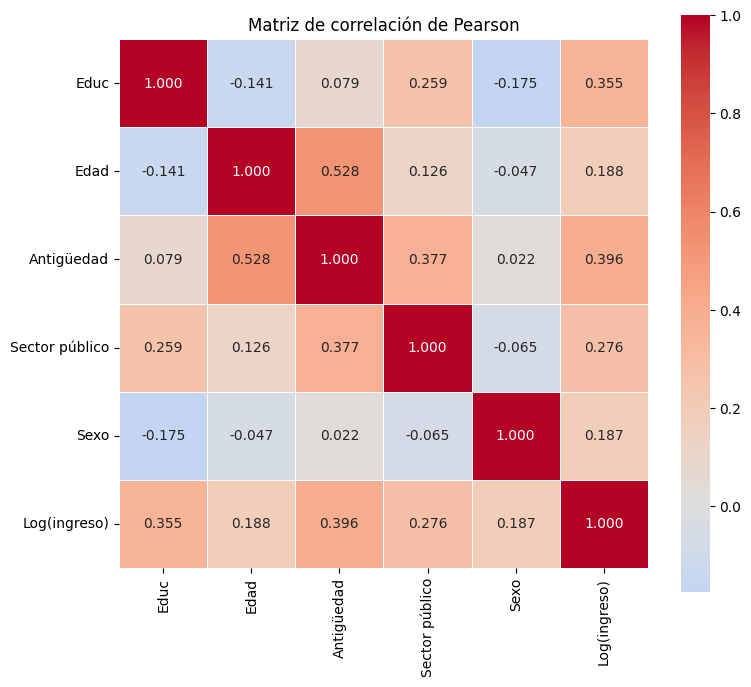

In [38]:
#h. Correlaciones

# Codificar variables categóricas como 0/1
df_l_ysos['ocup_num'] = (df_l_ysos['categoria_ocup'] == 'Asalariado/a público/a').astype(int)
df_l_ysos['sexo_num'] = (df_l_ysos['sexo'] == 'Hombre').astype(int)

# Matriz de correlación
corr = df_l_ysos[['anios_educ', 'edad', 'antiguedad', 'ocup_num', 'sexo_num', 'l_ysos_dep']].corr()
print(corr.round(3))

# Heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            xticklabels=['Educ', 'Edad', 'Antigüedad', 'Sector público', 'Sexo', 'Log(ingreso)'],
            yticklabels=['Educ', 'Edad', 'Antigüedad', 'Sector público', 'Sexo', 'Log(ingreso)'])
plt.title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.show()



## h2. Conclusiones de correlación

- La matriz de correlación muestra que todas las variables presentan correlación positiva con el ingreso logaritmizado, siendo antigüedad (0.396) y educación (0.355) las de mayor asociación.
- No se detecta multicolinealidad severa entre predictores, siendo la correlación más alta la de edad-antigüedad (0.528), lo cual es esperable pero no problemático para el modelo.
- Destaca que sexo presenta correlación negativa con educación (-0.175), sugiriendo que las mujeres tienen mayor nivel educativo pero menor ingreso, lo que refuerza la evidencia de brecha salarial.

## **04. Tarea 2.3**
Investigar qué es y en qué condiciones conviene realizar la ESTANDARIZACIÓN de
variables numéricas en el contexto de regresión para la transformación de  variables predictoras numéricas

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Definir Variables númericas y Categoricas | Listo|
|b| Generar columna transformadora| Listo|
|c| Realizar transformación (UNicamente Categoricas a Binarias)| Listo|
_______________________________


## **Estandarización - Concepto teorico**

Es una transformación que se aplica a las variables predictoras númericas antes de ajustar el modelo

Existen varias técnicas de estandarización:
1. Z-score: z = (x-μ​)/σ , Buena cuando los datos son aproximadamente normales - Media = 0, SD = 1

2. Min-Max Scaling: z= (x-x min)/(x max - x min) , Escala entre [0-1], Muy sensible a outliers

3. Robust Scaler: z = (x - mediana)/ IQR , Recomendada cuando hay outliers

4. Max Abs Scaler z = (x - |x max|), Escala entre [-1,1], Útil cuadno los datos ya estan centrados

5. Log transform: z = log(x)

**IMPORTANTE: Es importante que la estandarización se haga luego de dividir el dataset en Train y Test, para evitar data leakage (fuga de datos)**

In [39]:
# a. Definir Variables númericas y Categoricas

categorical_columns = ['sexo', 'categoria_ocup']
numerical_columns = ['edad', 'anios_educ', 'antiguedad']


In [40]:
# b. Generar la columna transformadora (Solo se aplica a categoricas para Binarias)
# Aun no se realiza la transformación de númericas porque estan todos los datos del dataset

column_transform = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), categorical_columns), # cuando son dos categorías, elimina una.

    #(StandardScaler(), numerical_columns), # comentado mientras no se decida estandarizar
    remainder='passthrough', # deja el resto de las columnas sin transformar
    verbose_feature_names_out=False)

In [64]:
# Realizar la transformación (Variable respuesta)

df_l_ysos_transf = pd.DataFrame(
    column_transform.fit_transform(df_l_ysos),
    columns=column_transform.get_feature_names_out()
)

# Convertir todas las columnas a numeric
df_l_ysos_transf = df_l_ysos_transf.apply(pd.to_numeric, errors='coerce')

df_l_ysos_transf.head()

,sexo_Mujer,categoria_ocup_Asalariado/a público/a,edad,anios_educ,antiguedad,log1_ysos_dep,l_ysos_dep,rango_edad,rango_antig,ocup_num,sexo_num
0,0.0,0.0,70.0,6.0,7.0,9.798183,9.798127,NaN,NaN,0,1
1,0.0,1.0,52.0,6.0,32.0,10.778977,10.778956,NaN,NaN,1,1
2,1.0,0.0,42.0,16.0,0.0,10.404293,10.404263,NaN,NaN,0,0
3,1.0,0.0,29.0,8.0,1.0,7.783641,7.783224,NaN,NaN,0,0
4,0.0,0.0,37.0,6.0,4.0,10.043293,10.043249,NaN,NaN,0,1


## **05. Tarea 2.4**
Realizar al menos tres derivaciones del modelo 2 (2.a, 2.b, 2.c) cada una con mayor grado en el polinomio. Analizar los resultados y conclusiones, considerando particularmente la evidencia acerca del problema del sobreajuste. Nota: puede ser seleccionada otra variable para realizar la regresión polinómica, con miras a un mejor desempeño

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Partición del dataset | Listo |
|b| X_train| Listo|
|c| X_test| Listo|
_______________________
*Modelo 1: Modelo lineal simple - anios educación.*
|# | Tarea | Estado|
|---|---|---|
|Mod_1a| Defino x_train | Listo |
|Mod_1b| Defino x_test| Listo|
|Mod_1c|Entreno el modelo| Listo|
|Mod_1d| Interpretación de los coeficientes| Listo|
|Mod_1e| Coeficiente de determinación R2| Listo|
|Mod_1f| Plot| Listo|
|Mod_1g| Predicción| Listo|
|Mod_1h| Error medio cuadratico_train| Listo|
|Mod_1i| Error medio cuadratico_test| Listo|
|Mod_1j| Plot outputs| Listo|
_________________________
*Modelo 2: Regresión polinomica - anios educación*
|# | Tarea | Estado|
|---|---|---|
|Mod_2a| Defino x_train y X_test| Listo |
|Mod_2b| Entreno el modelo| Listo|
|Mod_2c| Coeficientes de regresión| Listo|
|Mod_2d| Coeficeintes de determinación (R2)| Listo|
|Mod_2e| Realizo predicción| Listo|
|Mod_2f| Error cuadratico medio_train| Listo|
|Mod_2g| Error cuadratico medio_test| Listo|
____________________________
*Modelo 3*
|# | Tarea | Estado|
|---|---|---|
|Mod_3a|Completar |Listo|
|Mod_3b|Completar |Listo|
|Mod_3c|Completar |Listo|
|Mod_3d|Completar |Listo|

In [65]:
# a: Partición del dataset

X_train, X_test, y_train, y_test = train_test_split(df_l_ysos_transf[['edad', 'sexo_Mujer', 'anios_educ', 'antiguedad', 'categoria_ocup_Asalariado/a público/a']], \
                                                    df_l_ysos_transf['l_ysos_dep'],
                                                    test_size=0.20,
                                                    random_state=1234)

## *Consideraciones de la partición*

- Se seleccionan el 80 % de los datos para Entrenar el modelo y el 20 % para Testear (test_size = 0.20)

- Se elige una semilla aleatoria: Valor inicial que se le da a un generador de números pseudoaleatorios)

- Esto hace que si bien el número generado por el algoritmo es aleatorio, el mismo se repite cuando se realizan los distintos modelos, lo que permite compararlos entre si.

In [66]:
# b Defino X_train

X_train

,edad,sexo_Mujer,anios_educ,antiguedad,categoria_ocup_Asalariado/a público/a
18823,61.0,0.0,10.0,12.0,1.0
24775,27.0,1.0,10.0,2.0,0.0
5417,27.0,0.0,15.0,2.0,0.0
582,60.0,0.0,15.0,3.0,0.0
23025,42.0,1.0,15.0,6.0,0.0
...,...,...,...,...,...
32399,46.0,0.0,6.0,0.0,0.0
17048,29.0,1.0,11.0,2.0,0.0
23924,48.0,1.0,12.0,20.0,0.0
34086,32.0,0.0,9.0,3.0,0.0


In [67]:
# c. Defino X_test
X_test

,edad,sexo_Mujer,anios_educ,antiguedad,categoria_ocup_Asalariado/a público/a
7324,24.0,0.0,21.0,3.0,0.0
14262,42.0,1.0,9.0,9.0,0.0
12308,57.0,1.0,17.0,2.0,1.0
26097,46.0,1.0,9.0,0.0,0.0
35889,54.0,1.0,12.0,37.0,1.0
...,...,...,...,...,...
6210,61.0,1.0,6.0,0.0,0.0
32102,43.0,1.0,4.0,5.0,0.0
28894,37.0,1.0,17.0,1.0,0.0
33344,64.0,0.0,15.0,33.0,1.0


#Modelo 1.

Modelo lineal simple: una sola variable independiente. Utilizamos double bracket para mantener estructura de dataframe (sklearn sólo acepta objetos de 2D en train; un sólo paréntesis recto devuelve una Serie, dos paréntesis rectos devuelven un DataFrame).

In [68]:
# Mod_1a: Defino X_train

type(X_train['anios_educ'])

pandas.core.series.Series

In [69]:
# Mod_1b: Defino X_train (No deberia decir X_test?)

type(X_train[['anios_educ']])

pandas.core.frame.DataFrame

In [70]:
# Mod_1c: Entreno el modelo

#Defino el modelo
reg = linear_model.LinearRegression()

mod1_X_train = X_train[['anios_educ']]
mod1_X_test = X_test[['anios_educ']]

mod1 = reg.fit(mod1_X_train, y_train)

In [71]:
# Mod_1d: regression coefficients

print('Coefficients: ', mod1.coef_)
print('Intercept: ', mod1.intercept_ )

print('Cuando solamente la variable de respuesta fue transformada mediante el logaritmo, el coeficiente beta se interpreta como una variación de ',
     np.around((np.exp(mod1.coef_)-1)*100, 2), '% de la variable de respuesta por cada unidad de variación de la variable independiente')

Coefficients:  [0.05762114]
Intercept:  9.298664274869816
Cuando solamente la variable de respuesta fue transformada mediante el logaritmo, el coeficiente beta se interpreta como una variación de  [5.93] % de la variable de respuesta por cada unidad de variación de la variable independiente


In [72]:
# Mod_1e: Coefficient of determination (R2)

mod1.score(mod1_X_test, y_test)

0.12329451470261588

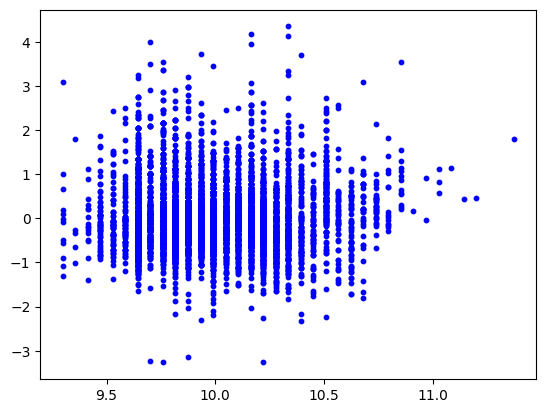

In [73]:
# Mod_1f: Plot

plt.scatter(mod1.predict(mod1_X_test), mod1.predict(mod1_X_test) - y_test,
            color = "blue", s = 10, label = 'Test data')

In [74]:
# Mod_1g: Predicción Modelo 1

# predicción en train
mod1_y_train_pred = mod1.predict(mod1_X_train)

# predicción en test
mod1_y_test_pred = mod1.predict(mod1_X_test)

In [75]:
# Mod_1h: Error medio cuadratico_train

mod1_mse_train = mean_squared_error(y_train, mod1_y_train_pred)
mod1_mse_train

0.4840089924851105

In [76]:
# Mod_1i: Error medio cuadratico_test

mod1_mse_test = mean_squared_error(y_test, mod1_y_test_pred)
mod1_mse_test

0.4834283901748652

## **Consideraciones MSE: Error cuadratico medio**

- Calcula diferencia entre el valor real y el predico (y-ytecho) elevado al cuadrado y luego promedia todo
- Los valores pueden ir de 0 < x < Inf. (Depende de la escala)
- Cuidado con escala en decimales, puede dar un error chico pero es engañoso.
- El MSE de Train y Test son similares por lo que no hay overfitting (No memorizo el train) ni underfitting (los errores son similares)


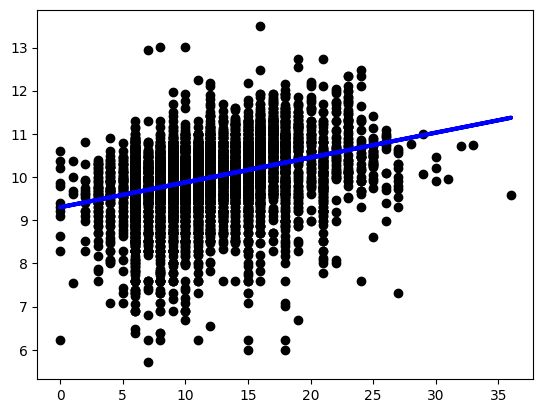

In [77]:
# Mod_1j: Plot outputs
plt.scatter(mod1_X_test, y_test, color="black")
plt.plot(mod1_X_test, mod1_y_test_pred, color="blue", linewidth=3)

#Modelo 2.

Regresión polinómica (generalización del modelo lineal simple). Utilizamos una función ad-hoc para crear el polinomio, descartando el intercepto (columna de valor 1), ya que lo trae por defecto reg.fit.

In [89]:
# Mod_2a: Defino X_train y X_Test (APlico X_train y X_test para distintos grados de polinomio)

mod2_X_train = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_train[['anios_educ']])
mod2_X_test = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_test[['anios_educ']])

mod2_X_train_d3 = PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_train[['anios_educ']])
mod2_X_test_d3 = PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_test[['anios_educ']])

mod2_X_train_d5 = PolynomialFeatures(degree=5, include_bias=False).fit_transform(X_train[['anios_educ']])
mod2_X_test_d5 = PolynomialFeatures(degree=5, include_bias=False).fit_transform(X_test[['anios_educ']])



Consideraciones:
- Al utilizar defree = 2, puede elevar potencia al cuadrado (maximo)
- include_bias=False: No agrega columnas de 1 (unos).


In [92]:
# Mod_2b: Entreno el modelo

mod2    = LinearRegression().fit(mod2_X_train,    y_train)
mod2_d3 = LinearRegression().fit(mod2_X_train_d3, y_train)
mod2_d5 = LinearRegression().fit(mod2_X_train_d5, y_train)

In [93]:
# Mod_2c: regression coefficients

modelos = {
    'Grado 2': mod2,
    'Grado 3': mod2_d3,
    'Grado 5': mod2_d5
}

for nombre, modelo in modelos.items():
    print(f'--- {nombre} ---')
    print(f'Coefficients: {modelo.coef_}')
    print(f'Intercept:    {modelo.intercept_}')
    print()

--- Grado 2 ---
Coefficients: [ 0.1030542  -0.00177063]
Intercept:    9.047575482410256

--- Grado 3 ---
Coefficients: [ 0.00315023  0.00628199 -0.00019217]
Intercept:    9.404372985493248

--- Grado 5 ---
Coefficients: [ 3.82231387e-02 -1.92777580e-03  5.79122721e-04 -3.10882148e-05
  4.45220047e-07]
Intercept:    9.364072217096902



## Consideraciones de coeficientes

Grado 2:
 - β0 = Intercept = 9.0475
 - β1 = Coeficiente lineal = 0.103
 - β2 = Coeficiente cuadratico = -0.00177

 Grado 3:
 - β0 = Intercept = 9.404
 - β1 = Coeficiente lineal = 0.003
 - β2 = Coeficiente cuadratico = 0.006
 - β3 = Coeficiente Cúbico = -0.00019217

 Grado 5:
 - β0 = Intercept = 9.36
 - β1 = Coeficiente lineal = 3.822 e-02
 - β2 = Coeficiente cuadratico = 1.927e-03
 - β3 = Coeficiente Cúbico = -3.108e-05
 - β4 = Coeficiente Cuartico = -5.791e-04
 - β4 = Coeficiente Quintico = -3.108e-05



In [98]:
# Mod_2d: Coefficient of determination (R2)

print(f'R² Grado 2: {mod2.score(mod2_X_test, y_test):.4f}')
print(f'R² Grado 3: {mod2_d3.score(mod2_X_test_d3, y_test):.4f}')
print(f'R² Grado 5: {mod2_d5.score(mod2_X_test_d5, y_test):.4f}')


R² Grado 2: 0.1266
R² Grado 3: 0.1295
R² Grado 5: 0.1302


## Consideraciones de coeficiente de Determinacion (R2).
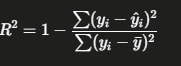
- Tiene que ser lo mas cercano a 1
-


In [99]:
# Mod_2e: Realizo Predicción

# Grado 2
mod2_y_train_pred    = mod2.predict(mod2_X_train)
mod2_y_test_pred     = mod2.predict(mod2_X_test)

# Grado 3
mod2_d3_y_train_pred = mod2_d3.predict(mod2_X_train_d3)
mod2_d3_y_test_pred  = mod2_d3.predict(mod2_X_test_d3)

# Grado 5
mod2_d5_y_train_pred = mod2_d5.predict(mod2_X_train_d5)
mod2_d5_y_test_pred  = mod2_d5.predict(mod2_X_test_d5)

In [100]:
# Mod_2f: Error cuadrático medio - Train

mod2_mse_train    = mean_squared_error(y_train, mod2_y_train_pred)
mod2_d3_mse_train = mean_squared_error(y_train, mod2_d3_y_train_pred)
mod2_d5_mse_train = mean_squared_error(y_train, mod2_d5_y_train_pred)

print(f'MSE Train Grado 2: {mod2_mse_train:.4f}')
print(f'MSE Train Grado 3: {mod2_d3_mse_train:.4f}')
print(f'MSE Train Grado 5: {mod2_d5_mse_train:.4f}')

MSE Train Grado 2: 0.4814
MSE Train Grado 3: 0.4795
MSE Train Grado 5: 0.4794


In [101]:
# Mod_2g: Error cuadrático medio - Test

mod2_mse_test    = mean_squared_error(y_test, mod2_y_test_pred)
mod2_d3_mse_test = mean_squared_error(y_test, mod2_d3_y_test_pred)
mod2_d5_mse_test = mean_squared_error(y_test, mod2_d5_y_test_pred)

print(f'MSE Test Grado 2: {mod2_mse_test:.4f}')
print(f'MSE Test Grado 3: {mod2_d3_mse_test:.4f}')
print(f'MSE Test Grado 5: {mod2_d5_mse_test:.4f}')

MSE Test Grado 2: 0.4816
MSE Test Grado 3: 0.4800
MSE Test Grado 5: 0.4796


In [102]:
print(f'         Train      Test')
print(f'Grado 2: {mod2_mse_train:.4f} | {mod2_mse_test:.4f}')
print(f'Grado 3: {mod2_d3_mse_train:.4f} | {mod2_d3_mse_test:.4f}')
print(f'Grado 5: {mod2_d5_mse_train:.4f} | {mod2_d5_mse_test:.4f}')

         Train      Test
Grado 2: 0.4814 | 0.4816
Grado 3: 0.4795 | 0.4800
Grado 5: 0.4794 | 0.4796


## Consideraciones modelo 2

- No hay overfitting: MSE train y test son similares
- La mejora es muy poca
- A partir de grado 3 se estabiliza el modelo.

#Modelo 3.

Regresión polinómica (generalización del modelo lineal simple). Utilizamos una función ad-hoc para crear el polinomio, descartando el intercepto (columna de valor 1), ya que lo trae por defecto reg.fit.

                            OLS Regression Results                            
Dep. Variable:             l_ysos_dep   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     2969.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        19:09:11   Log-Likelihood:                -27581.
No. Observations:               29908   AIC:                         5.517e+04
Df Residuals:                   29902   BIC:                         5.522e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

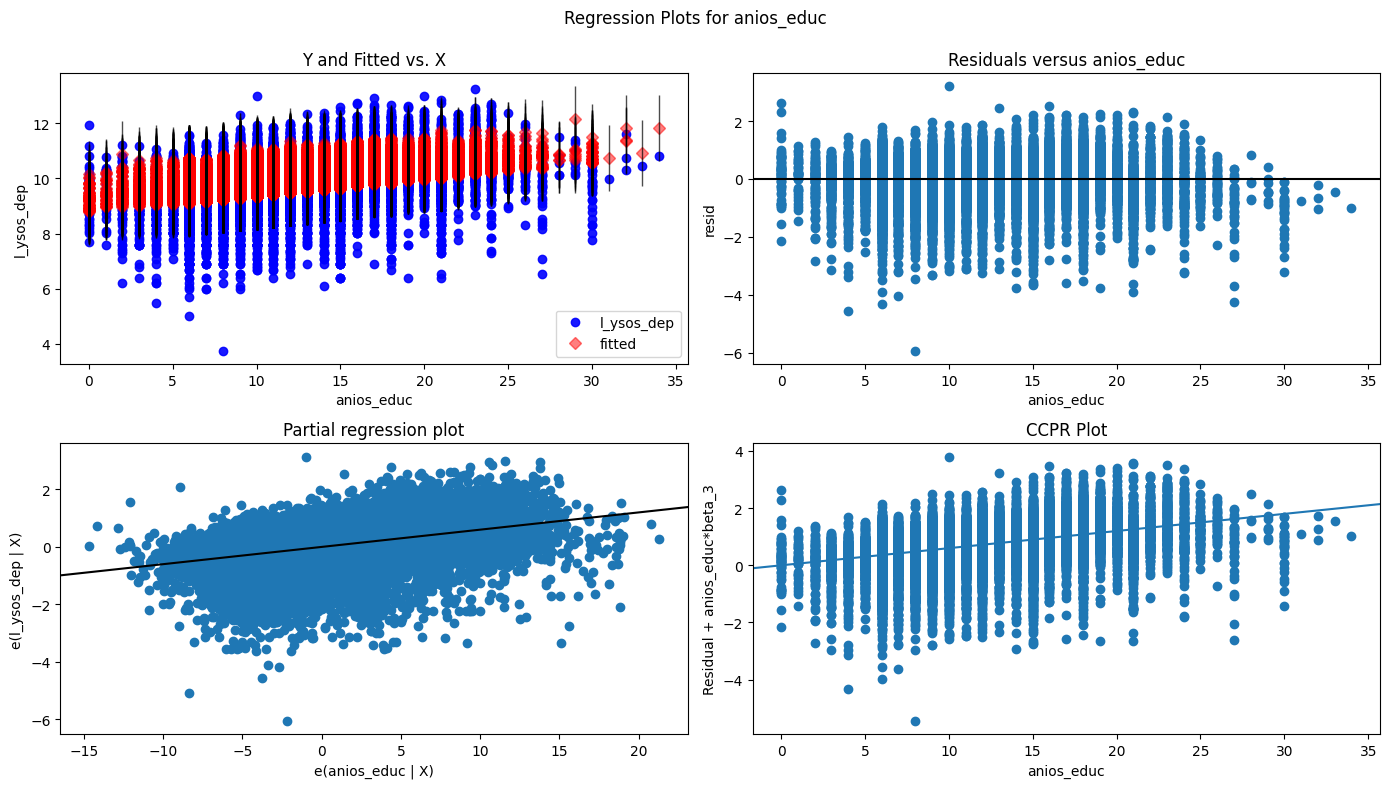

In [85]:
#Mod_3a: Regresión polinomica

#define response variable
mod3_y_train = y_train
mod3_y_test = y_test

#define predictor variables
mod3_X_train = X_train
mod3_X_test = X_test

#add constant to predictor variables
mod3_X_train = sm.add_constant(mod3_X_train)
mod3_X_test = sm.add_constant(mod3_X_test)

#fit linear regression model
mod3 = sm.OLS(mod3_y_train, mod3_X_train).fit()

#view model summary
print(mod3.summary())

# modify figure size
fig = plt.figure(figsize=(14, 8))

# creating regression plots
fig = sm.graphics.plot_regress_exog(mod3,
                                    'anios_educ',
                                    fig=fig)

In [86]:
#Mod_3b:

# predicción en train
mod3_y_train_pred = mod3.predict(mod3_X_train)

# predicción en test
mod3_y_test_pred = mod3.predict(mod3_X_test)

In [87]:
#Mod_3c:

mod3_mse_train = mean_squared_error(mod3_y_train, mod3_y_train_pred)
mod3_mse_train

0.3702760646178663

In [88]:
#Mod_3d:

mod3_mse_test = mean_squared_error(mod3_y_test, mod3_y_test_pred)
mod3_mse_test

0.3736517352939237

## **06. Tarea 2.5**
- Incorporar más variables. Analizar los resultados y conclusiones, considerando
particularmente la evidencia acerca del problema del sobreajuste.
-  Conviene hacerlo desde el principio (preparación de los datos)

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Variables| Comenzado |

In [ ]:
# Realizar: Buscar variables y hacer el EDA.

# Parentesis 1: Pipeline

¿Qué es el pipeline en machine learning? Los pipelines de datos se caracterizan por definir el conjunto de pasos o fases y las tecnologías involucradas en un proceso de movimiento o procesamiento de datos.

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Make Pipeline | No realizado|
|b| Crear Pipe, entrenar, predecir| No realizado|
|c|Print Error train y test| No realizado|

In [ ]:
#a.

pipeline = make_pipeline(StandardScaler(), LinearRegression())

In [ ]:
#b.

# creating a pipe using the make_pipeline method
pipeline = make_pipeline(StandardScaler(),
                         LinearRegression())

#fitting data into the model
pipeline.fit(X_train, y_train)

# predicting values
y_test_pred = pipeline.predict(X_test)
y_train_pred = pipeline.predict(X_train)

In [ ]:
#c.

print('Model Error Train: %.4f' % mean_squared_error(y_train, y_train_pred))
print('Model Error Test: %.4f' % mean_squared_error(y_test, y_test_pred))

# Parentesis 2: Validación cruzada

- Información de la función **cross_val_score**: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

- Información de scoring: https://scikit-learn.org/stable/modules/model_evaluation.html

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| k_folds| No realizado|
|b| CV_results| No realizado|
|c| Promedio| No realizado|
|d| Completar| No realizado|
|e| Error medio cuadratico| No realizado|
|f| Imprimir resultados | NO realizado|
|g| | No realizado|







In [ ]:
# a. K_folds

k_folds = 10

In [ ]:
# b. CV_results

cv_results = cross_val_score(pipeline, X = X_train, y = y_train, cv = k_folds, scoring='neg_mean_squared_error')
print('CV Error for a %s folds: \n%s' %(k_folds, -1*cv_results))

In [ ]:
# c. Calcula el promedio

average_cv = np.mean(cv_results)
print('Model Error CV: %.3f +/- %.3f' % (-1*average_cv,np.std(cv_results)))

In [ ]:
# d.

# Crear una lista con los números de fold
folds = np.arange(1, len(cv_results) + 1)

# Crear el gráfico
plt.figure(figsize=(8, 6))
plt.plot(folds, cv_results, marker='o', linestyle='-')
plt.title('Resultados de Validación Cruzada por Fold')
plt.xlabel('Fold')
plt.ylabel('Resultado de Validación Cruzada')
plt.grid(True)

# Agregar el valor de cada punto
for i, result in enumerate(cv_results):
    plt.text(folds[i], result, f'{result:.2f}', ha='center', va='bottom')

# Agregar el promedio
plt.axhline(y=average_cv, color='r', linestyle='--', label=f'Promedio: {average_cv:.2f}')
plt.legend()

plt.show()

In [ ]:
# e. Error medio cuadratico

error_train = mean_squared_error(y_train, y_train_pred)
error_test = mean_squared_error(y_test, y_test_pred)
error_cv = -1*np.mean(cv_results)

In [ ]:
# f. Imprimir resultados

print('Model Error Train: %.4f' % error_train)
print('Model Error CV   : %.4f' % error_cv)
print('Model Error Test : %.4f' % error_test)

In [ ]:
# g.

# Definir el orden de las etiquetas y los errores correspondientes
labels = ['Entrenamiento', 'CV', 'Test']
errors = [error_train, error_cv, error_test]

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
plt.bar(labels, errors, color=['skyblue', 'lightgreen', 'salmon'])  # Colores para las barras
plt.title('Comparación de Errores')
plt.ylabel('Error')
plt.ylim(0, max(errors) * 1.2)  # Ajustar el rango del eje y para dejar espacio para las etiquetas
plt.grid(axis='y')

# Mostrar los valores en las barras
for i, error in enumerate(errors):
    plt.text(i, error, f'{error:.4f}', ha='center', va='bottom')

plt.show()

## **07. Tarea 2.6**
Analizar los resultados de utilizar validación cruzada, ¿qué conclusiones obtiene?

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Completar| No realizado|

In [ ]:
# Realizar

## Realizamos implementación de CV con varias fórmulas (sesgos inductivos)

* aprovechamos salida de sm.OLS, por lo que agregamos una constante al dataset de train
* luego debemos descartar (o no indluir) la constante en el dataset de train al utilizar la función cross_validate
* por qué 'neg_mean_squared_error': https://stackoverflow.com/questions/48244219/is-sklearn-metrics-mean-squared-error-the-larger-the-better-negated

In [ ]:
model = LinearRegression()

In [ ]:
# preparación de datasets X_train, X_test con distintas variables independientes
independent_1 = ['anios_educ']
independent_2 = ['antiguedad']
independent_3 = ['edad', 'sexo_Mujer', 'anios_educ']
independent_4 = ['edad', 'sexo_Mujer', 'anios_educ', 'antiguedad', 'categoria_ocup_Asalariado/a público/a']

In [ ]:
# Aplicamos CV para la comparativa en train y test
CV_1_X_train = sm.add_constant(X_train[independent_1])
CV_2_X_train = sm.add_constant(X_train[independent_2])
CV_3_X_train = sm.add_constant(X_train[independent_3])
CV_4_X_train = sm.add_constant(X_train[independent_4])

CV_1_X_test = sm.add_constant(X_test[independent_1])
CV_2_X_test = sm.add_constant(X_test[independent_2])
CV_3_X_test = sm.add_constant(X_test[independent_3])
CV_4_X_test = sm.add_constant(X_test[independent_4])

In [ ]:
# ajuste en datos de entrenamiento
modCV_1 = sm.OLS(y_train, CV_1_X_train).fit()
modCV_2 = sm.OLS(y_train, CV_2_X_train).fit()
modCV_3 = sm.OLS(y_train, CV_3_X_train).fit()
modCV_4 = sm.OLS(y_train, CV_4_X_train).fit()

In [ ]:
# predicción en datos de entrenamiento
CV_1_y_train_pred = modCV_1.predict(CV_1_X_train)
CV_2_y_train_pred = modCV_2.predict(CV_2_X_train)
CV_3_y_train_pred = modCV_3.predict(CV_3_X_train)
CV_4_y_train_pred = modCV_4.predict(CV_4_X_train)

# predicción en datos de test
CV_1_y_test_pred = modCV_1.predict(CV_1_X_test)
CV_2_y_test_pred = modCV_2.predict(CV_2_X_test)
CV_3_y_test_pred = modCV_3.predict(CV_3_X_test)
CV_4_y_test_pred = modCV_4.predict(CV_4_X_test)

In [ ]:
# MSE en train
CV_1_mse_train = mean_squared_error(y_train, CV_1_y_train_pred)
CV_2_mse_train = mean_squared_error(y_train, CV_2_y_train_pred)
CV_3_mse_train = mean_squared_error(y_train, CV_3_y_train_pred)
CV_4_mse_train = mean_squared_error(y_train, CV_4_y_train_pred)

# MSE en test
CV_1_mse_test = mean_squared_error(y_test, CV_1_y_test_pred)
CV_2_mse_test = mean_squared_error(y_test, CV_2_y_test_pred)
CV_3_mse_test = mean_squared_error(y_test, CV_3_y_test_pred)
CV_4_mse_test = mean_squared_error(y_test, CV_4_y_test_pred)

# MSE en Cross-validation: no incluimos la constante en X_train
CV_1_mse_cv = -cross_validate(model, X_train[independent_1], y_train, cv=5, scoring=('neg_mean_squared_error'))['test_score'].mean()
CV_2_mse_cv = -cross_validate(model, X_train[independent_2], y_train, cv=5, scoring=('neg_mean_squared_error'))['test_score'].mean()
CV_3_mse_cv = -cross_validate(model, X_train[independent_3], y_train, cv=5, scoring=('neg_mean_squared_error'))['test_score'].mean()
CV_4_mse_cv = -cross_validate(model, X_train[independent_4], y_train, cv=5, scoring=('neg_mean_squared_error'))['test_score'].mean()

In [ ]:
# dataset para evaluación (comparación de MSE en train, test y CV)
evaluate = pd.DataFrame(
    {'mod': pd.Series(['CV_1', 'CV_2', 'CV_3', 'CV_4']).astype('category'),
     'mse_train': pd.Series([CV_1_mse_train, CV_2_mse_train, CV_3_mse_train, CV_4_mse_train]).astype('float64'),
     'mse_cv': pd.Series([CV_1_mse_cv, CV_2_mse_cv, CV_3_mse_cv, CV_4_mse_cv]).astype('float64'),
     'mse_test': pd.Series([CV_1_mse_test, CV_2_mse_test, CV_3_mse_test, CV_4_mse_test]).astype('float64')
    }
)

In [ ]:
# Plot para evaluación
plt.figure(figsize=(12, 6))

# Definir el ancho de las barras y el espacio entre grupos de barras
bar_width = 0.2
space = 0.05

# Posición de las barras en el eje x
r1 = np.arange(len(evaluate))
r2 = [x + bar_width + space for x in r1]
r3 = [x + 2 * (bar_width + space) for x in r1]

# Graficar los resultados
plt.bar(r1, evaluate['mse_train'], color='skyblue', width=bar_width, edgecolor='grey', label='mse_train')
plt.bar(r2, evaluate['mse_cv'], color='lightgreen', width=bar_width, edgecolor='grey', label='mse_cv')
plt.bar(r3, evaluate['mse_test'], color='salmon', width=bar_width, edgecolor='grey', label='mse_test')

# Mostrar los valores en cada barra
for i, row in enumerate(evaluate.iterrows()):
    plt.text(r1[i], row[1]['mse_train'], f'{row[1]["mse_train"]:.5f}', ha='center', va='bottom', fontsize=7)
    plt.text(r2[i], row[1]['mse_cv'], f'{row[1]["mse_cv"]:.5f}', ha='center', va='bottom', fontsize=7)
    plt.text(r3[i], row[1]['mse_test'], f'{row[1]["mse_test"]:.5f}', ha='center', va='bottom', fontsize=7)

# Añadir etiquetas y título
plt.xlabel('Modelos')
plt.ylabel('MSE')
plt.title('Comparación de MSE en Entrenamiento, Test y Validación Cruzada')

# Añadir leyenda y especificar posición
plt.legend(loc='upper right')

# Ajustar las etiquetas del eje x
plt.xticks([r + bar_width + space for r in range(len(evaluate))], evaluate['mod'])

# Mostrar la gráfica
plt.grid(True)
plt.show()

In [ ]:
evaluate

In [ ]:
# Definir el generador de particiones (en este caso, KFold con 5 particiones)
k_folds2 = KFold(n_splits=5)
df_subset = df_l_ysos_transf.sample(n=1000)  # Tomar un subconjunto de 50 filas
X = df_subset[['edad', 'sexo_Mujer', 'anios_educ', 'antiguedad', 'categoria_ocup_Asalariado/a público/a']].values
y = df_subset['l_ysos_dep'].values

# Realizar validación cruzada con 5 particiones
cv_results = cross_validate(model, X, y, cv=k_folds2, scoring=('neg_mean_squared_error', 'r2'), return_train_score=True)

In [ ]:
# Visualizar cómo se divide el conjunto de datos en cada iteración de validación cruzada
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (train_index, test_index) in enumerate(k_folds2.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    axes[i].scatter(X_train[:, 0], y_train, color='blue', label='Train')
    axes[i].scatter(X_test[:, 0], y_test, color='red', label='Test')
    axes[i].set_title(f'Fold {i+1}')
    axes[i].legend()

plt.suptitle('División del conjunto de datos en cada iteración de validación cruzada', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Calcular los porcentajes de entrenamiento y prueba en cada iteración
train_sizes = []
test_sizes = []
for train_index, test_index in k_folds2.split(X):
    train_size = len(train_index) / len(X) * 100
    test_size = len(test_index) / len(X) * 100
    train_sizes.append(train_size)
    test_sizes.append(test_size)

In [ ]:
# Visualizar los porcentajes de entrenamiento y prueba en barras apiladas para cada iteración
plt.figure(figsize=(10, 6))

bar_width = 0.5
index = np.arange(len(train_sizes))

plt.bar(index, train_sizes, color='blue', label='Entrenamiento', width=bar_width, alpha=0.7)
plt.bar(index, test_sizes, bottom=train_sizes, color='red', label='Prueba', width=bar_width, alpha=0.7)
plt.xlabel('Iteración de Validación Cruzada')
plt.ylabel('Porcentaje del Conjunto de Datos')
plt.title('Porcentajes de Entrenamiento y Prueba en cada Iteración de Validación Cruzada')
plt.xticks(index, np.arange(1, len(train_sizes) + 1))
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Regularización

### Parámetro de regularización:
Definir el parámetro de regularización alpha (en la clase se definió como lambda) es crucial al aplicar los modelos de regresión Ridge y Lasso. Este parámetro controla la fuerza de la regularización en el modelo. Cuanto mayor sea el valor de alpha, mayor será la penalización aplicada a los coeficientes del modelo.

- **Ridge Regression**: En Ridge Regression, se aplica la penalización L2 a los coeficientes del modelo. La función de costo que se minimiza incluye un término de regularización proporcional a la suma de los cuadrados de los coeficientes multiplicados por alpha.

- **Lasso Regression**: En Lasso Regression, se aplica la penalización L1 a los coeficientes del modelo. La función de costo que se minimiza incluye un término de regularización proporcional a la suma de los valores absolutos de los coeficientes multiplicados por alpha.

Entonces, definir alpha implica decidir cuánta importancia se le da a la regularización en comparación con el ajuste de los datos de entrenamiento.

In [ ]:
# Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo Ridge y realizar la validación cruzada
ridge = Ridge(alpha=1.0)  # Puedes ajustar el valor de alpha según sea necesario
ridge_cv_scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5)

print("Cross-validation scores for Ridge:")
print(ridge_cv_scores)
print("\nMean cross-validation score for Ridge:", ridge_cv_scores.mean())

In [ ]:
# Entrenar el modelo Lasso y realizar la validación cruzada
lasso = Lasso(alpha=1.0)  # Puedes ajustar el valor de alpha según sea necesario
lasso_cv_scores = cross_val_score(lasso, X_train_scaled, y_train, cv=5)

print("Cross-validation scores for Lasso:")
print(lasso_cv_scores)
print("\nMean cross-validation score for Lasso:", lasso_cv_scores.mean())

In [ ]:
print('Model Score CV and Lasso: %.3f +/- %.3f' % (np.mean(lasso_cv_scores),np.std(lasso_cv_scores)))

In [ ]:
error_cv_lasso = -1*np.mean(lasso_cv_scores)
error_cv_ridge = np.mean(ridge_cv_scores)

In [ ]:
data = {'Error Train':[error_train],
        'Error CV':[error_cv],
        'Error CV Lasso':[error_cv_lasso],
        'Error CV Ridge':[error_cv_ridge],
        'Error Test':[error_test]}

In [ ]:
error = pd.DataFrame(data)
error

In [ ]:
# Definir el orden de las etiquetas y los errores correspondientes
labels = ['Entrenamiento', 'CV', 'CV Lasso', 'CV Ridge', 'Test']
errors = [error_train, error_cv, error_cv_lasso, error_cv_ridge, error_test]

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
plt.bar(labels, errors, color=['skyblue', 'lightgreen', 'lightpink', 'palegoldenrod' , 'salmon'])  # Colores para las barras
plt.title('Comparación de Errores')
plt.ylabel('Error')
plt.ylim(0, max(errors) * 1.2)  # Ajustar el rango del eje y para dejar espacio para las etiquetas
plt.grid(axis='y')

# Mostrar los valores en las barras
for i, error in enumerate(errors):
    plt.text(i, error, f'{error:.4f}', ha='center', va='bottom')

plt.show()

## **08. Tarea 2.7**
Analizar los resultados al incorporar más variables y aplicar la regularización utilizando Ridge y Lasso, ¿qué conclusiones obtiene? ¿Se cumple la selección de variables al aplicar Lasso?

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Completar| No realizado|

In [ ]:
# Responder

## Definición del lambda

### Puntos a considerar al definir alpha:
- Puedes buscar el valor óptimo de alpha mediante técnicas como la búsqueda de cuadrícula (Grid Search) o la búsqueda aleatoria (Random Search) junto con la validación cruzada.
- La validación cruzada puede ayudar a evaluar cómo diferentes valores de alpha afectan el rendimiento del modelo en datos no vistos.
- Trade-off entre sesgo y varianza:
    - Un alpha más grande aumentará la regularización, lo que puede reducir la varianza del modelo pero aumentar su sesgo.
    - Un alpha más pequeño permite que el modelo sea más flexible, pero puede llevar a una mayor varianza y un posible sobreajuste a los datos de entrenamiento.

### Interpretación de coeficientes:
alpha también afecta la magnitud de los coeficientes en el modelo. Valores más altos de alpha pueden conducir a coeficientes más pequeños, lo que puede hacer que el modelo sea más interpretable y menos propenso al sobreajuste.

En resumen, la elección de alpha depende de tus objetivos específicos y del equilibrio entre la capacidad de ajuste del modelo y la capacidad de generalización. Experimentar con diferentes valores de alpha y evaluar el rendimiento del modelo en datos de prueba o mediante validación cruzada puede ayudarte a determinar el valor óptimo para tu aplicación específica.

In [ ]:
X = df_l_ysos_transf[['edad', 'sexo_Mujer', 'anios_educ', 'antiguedad', 'categoria_ocup_Asalariado/a público/a']]
y = df_l_ysos_transf['l_ysos_dep']

In [ ]:
# Renombrar X y y
nombres_nuevos = {
    'edad': 'edad',
    'sexo_Mujer': 'es_mujer',
    'anios_educ': 'anios_educ',
    'antiguedad': 'antiguedad',
    'categoria_ocup_Asalariado/a público/a': 'asalariado_publico',
}

X.rename(columns=nombres_nuevos, inplace=True)

In [ ]:
# Rango de valores para alpha
alphas = np.logspace(-3, 3, 100)

In [ ]:
# Obtener los índices de los valores de alpha
indices = np.arange(len(alphas))

# Plotear alphas en escala logarítmica
plt.figure(figsize=(10, 6))
plt.plot(indices, alphas, marker='o')
plt.title('Variación de alphas')
plt.xlabel('Índice de alpha')
plt.ylabel('Valor de alpha')
plt.grid(True)
plt.show()

In [ ]:
# Ridge
ridge_coefs = []
ridge_train_scores, ridge_val_scores = validation_curve(Ridge(), X_train_scaled, y_train, param_name="alpha", param_range=alphas, cv=5)
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

In [ ]:
# Lasso
lasso_coefs = []
lasso_train_scores, lasso_val_scores = validation_curve(Lasso(), X_train_scaled, y_train, param_name="alpha", param_range=alphas, cv=5)
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

In [ ]:
# Graficar coeficientes vs alpha para Ridge
plt.figure(figsize=(10, 5))
for i in range(X.shape[1]):
    plt.plot(alphas, ridge_coefs[:, i], label=X.columns[i])
plt.xscale('log')
plt.title('Ridge Coefficients vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.legend()
plt.show()

In [ ]:
# Graficar coeficientes vs alpha para Lasso
plt.figure(figsize=(10, 5))
for i in range(X.shape[1]):
    plt.plot(alphas, lasso_coefs[:, i], label=X.columns[i])
plt.xscale('log')
plt.title('Lasso Coefficients vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.legend()
plt.show()

### Coeficientes vs Alpha para Ridge y Lasso:
En las gráficas de coeficientes vs alpha para Ridge y Lasso, cada línea representa cómo cambia el valor de los coeficientes de las características a medida que aumenta el parámetro de regularización (alpha), en clase se detalló como lambda.

A medida que alpha aumenta, la regularización penaliza más los coeficientes, lo que conduce a una disminución de su magnitud.
- En Ridge, los coeficientes disminuyen gradualmente a medida que alpha aumenta, pero nunca se vuelven exactamente cero.
- En Lasso, algunos coeficientes pueden volverse exactamente cero a medida que alpha aumenta, lo que lleva a una selección de características.

Después de ajustar un modelo de regresión Ridge o Lasso, puedes obtener los coeficientes de las características del modelo. Estos coeficientes se utilizan en la ecuación de regresión para predecir el valor de la variable objetivo. Aquí te muestro cómo sería la ecuación final con los coeficientes obtenidos:

**Para Ridge Regression**:
   Después de ajustar un modelo de regresión Ridge, puedes obtener los coeficientes de las características. La ecuación de regresión para Ridge sería:

   $ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n \ $

   Donde:
   - $\hat{y}$ es la variable objetivo predicha.
   - $\beta_0$ es el término de sesgo.
   - $\beta_1, \beta_2, \ldots, \beta_n $ son los coeficientes de las características.
   - $x_1, x_2, \ldots, x_n $ son los valores de las características correspondientes.

**Para Lasso Regression**:
   Después de ajustar un modelo de regresión Lasso, también puedes obtener los coeficientes de las características. La diferencia es que Lasso puede reducir algunos coeficientes a cero, lo que implica una selección de características. La ecuación de regresión para Lasso sería similar a la de Ridge, pero con algunos coeficientes igualados a cero:

   $ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n \$

   Donde algunos de los $\beta$ pueden ser cero, dependiendo de la regularización aplicada.

Por lo tanto, una vez que ajustas el modelo y obtienes los coeficientes $\beta$, puedes sustituir estos valores en la ecuación de regresión correspondiente junto con los valores de las características $x$ para obtener las predicciones $\hat{y}\$.

## Definición del lambda

### Puntos a considerar al definir alpha:
- Puedes buscar el valor óptimo de alpha mediante técnicas como la búsqueda de cuadrícula (Grid Search) o la búsqueda aleatoria (Random Search) junto con la validación cruzada.
- La validación cruzada puede ayudar a evaluar cómo diferentes valores de alpha afectan el rendimiento del modelo en datos no vistos.
- Trade-off entre sesgo y varianza:
    - Un alpha más grande aumentará la regularización, lo que puede reducir la varianza del modelo pero aumentar su sesgo.
    - Un alpha más pequeño permite que el modelo sea más flexible, pero puede llevar a una mayor varianza y un posible sobreajuste a los datos de entrenamiento.

### Interpretación de coeficientes:
alpha también afecta la magnitud de los coeficientes en el modelo. Valores más altos de alpha pueden conducir a coeficientes más pequeños, lo que puede hacer que el modelo sea más interpretable y menos propenso al sobreajuste.

En resumen, la elección de alpha depende de tus objetivos específicos y del equilibrio entre la capacidad de ajuste del modelo y la capacidad de generalización. Experimentar con diferentes valores de alpha y evaluar el rendimiento del modelo en datos de prueba o mediante validación cruzada puede ayudarte a determinar el valor óptimo para tu aplicación específica.

In [ ]:
X = df_l_ysos_transf[['edad', 'sexo_Mujer', 'anios_educ', 'antiguedad', 'categoria_ocup_Asalariado/a público/a']]
y = df_l_ysos_transf['l_ysos_dep']

In [ ]:
# Renombrar X y y
nombres_nuevos = {
    'edad': 'edad',
    'sexo_Mujer': 'es_mujer',
    'anios_educ': 'anios_educ',
    'antiguedad': 'antiguedad',
    'categoria_ocup_Asalariado/a público/a': 'asalariado_publico',
}

X.rename(columns=nombres_nuevos, inplace=True)

In [ ]:
# Rango de valores para alpha
alphas = np.logspace(-3, 3, 100)

In [ ]:
# Obtener los índices de los valores de alpha
indices = np.arange(len(alphas))

# Plotear alphas en escala logarítmica
plt.figure(figsize=(10, 6))
plt.plot(indices, alphas, marker='o')
plt.title('Variación de alphas')
plt.xlabel('Índice de alpha')
plt.ylabel('Valor de alpha')
plt.grid(True)
plt.show()

In [ ]:
# Ridge
ridge_coefs = []
ridge_train_scores, ridge_val_scores = validation_curve(Ridge(), X_train_scaled, y_train, param_name="alpha", param_range=alphas, cv=5)
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

In [ ]:
# Lasso
lasso_coefs = []
lasso_train_scores, lasso_val_scores = validation_curve(Lasso(), X_train_scaled, y_train, param_name="alpha", param_range=alphas, cv=5)
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

In [ ]:
# Graficar coeficientes vs alpha para Ridge
plt.figure(figsize=(10, 5))
for i in range(X.shape[1]):
    plt.plot(alphas, ridge_coefs[:, i], label=X.columns[i])
plt.xscale('log')
plt.title('Ridge Coefficients vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.legend()
plt.show()

In [ ]:
# Graficar coeficientes vs alpha para Lasso
plt.figure(figsize=(10, 5))
for i in range(X.shape[1]):
    plt.plot(alphas, lasso_coefs[:, i], label=X.columns[i])
plt.xscale('log')
plt.title('Lasso Coefficients vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.legend()
plt.show()

### Coeficientes vs Alpha para Ridge y Lasso:
En las gráficas de coeficientes vs alpha para Ridge y Lasso, cada línea representa cómo cambia el valor de los coeficientes de las características a medida que aumenta el parámetro de regularización (alpha), en clase se detalló como lambda.

A medida que alpha aumenta, la regularización penaliza más los coeficientes, lo que conduce a una disminución de su magnitud.
- En Ridge, los coeficientes disminuyen gradualmente a medida que alpha aumenta, pero nunca se vuelven exactamente cero.
- En Lasso, algunos coeficientes pueden volverse exactamente cero a medida que alpha aumenta, lo que lleva a una selección de características.

Después de ajustar un modelo de regresión Ridge o Lasso, puedes obtener los coeficientes de las características del modelo. Estos coeficientes se utilizan en la ecuación de regresión para predecir el valor de la variable objetivo. Aquí te muestro cómo sería la ecuación final con los coeficientes obtenidos:

**Para Ridge Regression**:
   Después de ajustar un modelo de regresión Ridge, puedes obtener los coeficientes de las características. La ecuación de regresión para Ridge sería:

   $ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n \ $

   Donde:
   - $\hat{y}$ es la variable objetivo predicha.
   - $\beta_0$ es el término de sesgo.
   - $\beta_1, \beta_2, \ldots, \beta_n $ son los coeficientes de las características.
   - $x_1, x_2, \ldots, x_n $ son los valores de las características correspondientes.

**Para Lasso Regression**:
   Después de ajustar un modelo de regresión Lasso, también puedes obtener los coeficientes de las características. La diferencia es que Lasso puede reducir algunos coeficientes a cero, lo que implica una selección de características. La ecuación de regresión para Lasso sería similar a la de Ridge, pero con algunos coeficientes igualados a cero:

   $ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n \$

   Donde algunos de los $\beta$ pueden ser cero, dependiendo de la regularización aplicada.

Por lo tanto, una vez que ajustas el modelo y obtienes los coeficientes $\beta$, puedes sustituir estos valores en la ecuación de regresión correspondiente junto con los valores de las características $x$ para obtener las predicciones $\hat{y}\$.

## **09. Tarea 2.8**
¿Qué conclusiones obtiene? ¿Se cumple la selección de variables al aplicar Lasso?  Agregar más variables y comentar los resultados

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Completar| No realizado|

In [ ]:
# Realizar

## **10. Tarea 2.9**
Ídem a 2.8, pero usando Ridge

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Completar| No realizado|

In [ ]:
# Realizar